# DESI PV Y1 $z$-bin TFR Calibration w/o zero-pointing

In redshift bins of width 0.001 (or 0.005), identify DESI observations with measurements suitable for the Tully-Fisher relation. Export the SGA IDs of the TFR galaxies and apply a multi-bin joint fit to calibrate the TFR at $0.4R_{26}$.  Only use those galaxies identified as being part of the central population based on an elliptical fit within each redshift bin.

Version: **27 July 2026**

**Note:** This requires using a subclassed version of `hyperfit`.

In [119]:
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
from matplotlib import cm, colors
from matplotlib.patches import Ellipse
import matplotlib as mpl

# We have more than 10 redshift bins, so we need to change the default color map so that they are all plotted with different colors
# from cycler import cycler
# plt.rcParams['axes.prop_cycle'] = cycler('color', plt.get_cmap('tab20').colors)

import ligo.skymap.plot

from astropy.table import Table, vstack, join
from astropy.coordinates import SkyCoord, Distance
from astropy.cosmology import Planck18, FlatLambdaCDM
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
from astropy import units as u
from astropy import constants as c
from astropy import constants as const
from astropy.io import fits

from cosmoprimo.fiducial import DESI

from scipy.spatial.distance import cdist, euclidean

import os

from corner import corner, hist2d
import math
import pickle

from sklearn.covariance import EllipticEnvelope
from matplotlib.patches import Ellipse
from scipy.stats import chi2

from tqdm import tqdm
from hdbscan import HDBSCAN
from scipy.stats import binned_statistic
from matplotlib.projections import get_projection_names

from desiutil.plots import init_sky

# Custom functions / classes
import sys
# sys.path.insert(1, '/global/u1/k/kadglass/DESI_SGA/TF/')
# sys.path.insert(1, '/Users/kdouglass/Documents/Research/DESI/PV_survey/code/TF/')
sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from help_functions import adjust_lightness
from line_fits import hyperfit_line_multi
from TF_photoCorrect import BASS_corr, MW_dust, k_corr, internal_dust
from z_CMB_convert import convert_z_frame

In [120]:
# Base values for later conversions (all in units in km/s).
c_kms = c.c.to_value('km/s')

h = 1.
H0 = 100*h

q0 = 0.2

# Access SGA Iron Data

The following selections have already been applied:
* `DELTACHI2 > 25` & `ZWARN = 0` for the centers
* $10 < V < 1000$ km/s and $\Delta V / V_\text{min}$ for the observations at $0.4R_{26}$
* Visual inspection

In [121]:
# sgapath = '/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y1'
sgapath = 'vrot_cats'
# sgafits = os.path.join(sgapath, 'SGA-2020_iron_Vrot_v5.fits')
sgafits = os.path.join(sgapath, 'SGA-2020_loa_Vrot_v5.fits')

sgatab = Table.read(sgafits)
sgatab[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,PHOTSYS,V_0p4R26,V_0p4R26_ERR,LOGVROT,LOGVROT_ERR,logV_SBcorr,logV_correction_factor,logV_SBcorr_err
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,bytes1,float64,float64,float64,float64,float64,float64,float64
20,SGA-2020 20,SDSSJ173412.71+572041.6,3331584,263.5529355,57.34490699999999,S?,152.58,0.4487454,0.5333349,0.08364453,24.92448,18.036,False,LEDA-20181114,5,SDSSJ173412.71+572041.6,1,True,263.5529355,57.34490699999999,0.4487454,2635p572,263.55294849855886,57.344862145664294,0.4460123,SB26,152.3756,0.5778338,263.5528114673963,57.34481025685253,10.459747,5.9780583,5.751067,4.821581,1.4858595,3.4448266,5.1149526,6.748707,8.426254,9.720271,11.022999,12.0887985,13.380368,20.656942,20.044735,19.40886,19.194794,18.66572,18.231262,18.599888,18.123905,17.745926,18.256256,17.807074,17.476473,18.040592,17.60353,17.319197,17.926336,17.500519,17.228865,17.85259,17.42695,17.180876,17.811844,17.39206,17.151228,17.783718,17.36542,17.143204,0.02069058,0.026094317,0.03480586,0.05076174,0.08751116,0.10309491,0.08337893,0.10982923,0.13734566,0.031223593,0.046367057,0.0777883,0.015935475,0.020728666,0.032657374,0.012760426,0.014699919,0.022893604,0.010505663,0.011998588,0.018923525,0.010358521,0.011374098,0.017719442,0.010557283,0.0112259,0.017149422,0.010553381,0.011049819,0.017135512,0.010413324,0.010993488,0.01699026,0.010291049,0.010862263,0.017057167,17.6411,0.6362121,0.53480667,2.8045392,1.7123051,17.22401,0.6144014,0.53440714,2.7180903,2.1161501,17.062769,0.44818503,0.43006793,3.1755726,0.9

In [122]:
# sgatab['SGA_ID'] = sgatab['SGA_ID'].astype(int)
# sgatab['PHOTSYS'] = sgatab['PHOTSYS_2'] 

In [123]:
### Make sure if we don't have a measurement in one of the bands, we switch the value to NaN
for col in ['G_MAG_SB26', 'R_MAG_SB26','Z_MAG_SB26']:
    sgatab[col][sgatab[col] == -1] = np.nan

## Compute maximum volume for each galaxy

Since the SGA is a size-limited catalog ($D_{26} > 0.2$ arcmin), there is a maximum volume within which each galaxy could be located to be included in the SGA.  Let's calculate that maximum volume so that we can use it as a weight in the TFR calibration.

In [124]:
Planck18_h = FlatLambdaCDM(H0=100, Om0=0.3151)

In [125]:
dist = Distance(z=np.abs(sgatab['Z_DESI']), cosmology=Planck18_h)

sgatab['D26_kpc'] = 2*dist.to('kpc')*np.tan(0.5*sgatab['D26']*u.arcmin)

sgatab['DIST_MAX'] = 0.5*sgatab['D26_kpc']/np.tan(0.1*u.arcmin)

dist_max = Distance(z=0.1, cosmology=Planck18_h)

sgatab['MAX_VOL_FRAC'] = sgatab['DIST_MAX'].to('Mpc')**3 / dist_max.to('Mpc')**3

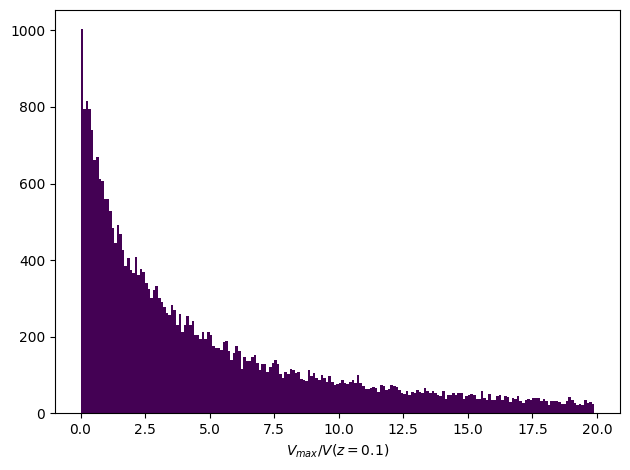

In [126]:
plt.figure(tight_layout=True)

plt.hist(sgatab['MAX_VOL_FRAC'], np.arange(0, 20, 0.1))

plt.xlabel('$V_{max}$/$V(z = 0.1)$');

## Convert to CMB frame

In [127]:
sgatab['Z_DESI_CMB'] = convert_z_frame(sgatab['Z_DESI'], sgatab['RA'], sgatab['DEC'])

In [128]:
np.min(sgatab["Z_DESI"]), len(sgatab[sgatab["Z_DESI"]<0])

(-0.0006685686534794439, 4)

In [129]:
np.median(sgatab['V_0p4R26_ERR']/sgatab['V_0p4R26'])

0.08745883413801092

# Load Morphological Classification

## SSL

As an alternative to morphological classification of the galaxies, we also produced a classification based on the SSL sorter (using a nearest-neighbor query; Largett et al., in prep.). The classification ignored the Hubble sub-types and grouped the galaxies into four main categories:
1. Spiral
2. Elliptical
3. Lenticular
4. Irregular

Let's also load this table and add it to the SGA table.

In [130]:
# ai_morphpath = '/global/cfs/cdirs/desi/science/td/pv'
ai_morphpath = '.'
# ai_morphpath = '/global/cfs/cdirs/desi/science/td/pv/SGA2020'
# ai_morphcsv = os.path.join(ai_morphpath, 'sga10278_morphologies_model_analysis.csv')
ai_morphcsv = '/global/homes/s/sgmoore1/DESI_SGA/TF/Y3/SGAY3TFMorphologies.csv'
ai_morphtab = Table.read(ai_morphcsv)
ai_morphtab

SGA_ID,Predicted_Type_spiral,Predicted_Type_elliptical,Predicted_Type_irregular,Predicted_Type_lenticular,Predicted_Type
float64,str6,str10,str9,str10,str10
218203.0,Other,Other,Irregular,Other,Irregular
218205.0,Other,Other,Irregular,Other,Irregular
218239.0,Other,Other,Irregular,Other,Irregular
218275.0,Other,Other,Irregular,Other,Irregular
218304.0,Spiral,Other,Other,Other,Spiral
218367.0,Other,Other,Irregular,Other,Irregular
218376.0,Spiral,Other,Other,Other,Spiral
218201.0,Other,Other,Irregular,Other,Irregular
218385.0,Spiral,Other,Other,Other,Spiral


### Combine ML morphtypes with SGA catalog

In [131]:
sgatab = join(sgatab, ai_morphtab['SGA_ID', 'Predicted_Type'], keys='SGA_ID', join_type='left')

# Rename Predicted_Type to MORPHTYPE_AI
sgatab['Predicted_Type'].name = 'MORPHTYPE_AI'

## John Lucey's VI results

https://astro.dur.ac.uk/~jrl/DESI_TF_Y3/index.html

We are only considering galaxies that he considers bad for TF (strong asymmetry, double galaxies, stellar contamination).

In [132]:
lucey_VIpath = 'VI_JohnLucey/'

rejects = lucey_VIpath + 'REJECTS.txt'

reject_tab = Table.read(rejects, format='ascii.commented_header')
reject_tab['VI'] = 'reject'
reject_tab

SGA_ID,DESI_NAME,RA,Dec,z_desi,BA,G_R,G_R_err,V_0p4R26,V_0p4R26_err,R_MAG_SB26_CORR,R_MAG_SB26_ERR_CORR,LOGDIST_AVG,LOGDIST_AVG_ERR,MAIN,VI
int64,str22,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,int64,str6
692,DESIXJ12411157+1819512,190.298193,18.330884,0.0691,0.5,0.4903,0.0288,85,6,16.7987,0.1126,0.1983,0.0552,0,reject
2526,DESIXJ10124098+4543539,153.170765,45.731651,0.0241,0.3969,0.3677,0.0227,46,6,16.4224,0.1398,0.1804,0.0717,0,reject
2804,DESIXJ07581109+3420293,119.546191,34.341483,0.0198,0.2924,0.5585,0.035,121,5,14.3538,0.1607,-0.0479,0.0527,0,reject
3420,DESIXJ01135557+0034028,18.48153,0.567434,0.0418,0.761,0.3742,0.0169,82,22,16.5482,0.0542,0.0391,0.1185,0,reject
5964,DESIXJ16261820+4219580,246.57584,42.332773,0.0465,0.9154,0.3389,0.0122,41,23,16.543,0.0311,0.4811,0.2514,0,reject
6243,DESIXJ13403564+1214293,205.148492,12.241463,0.0927,0.6161,0.8506,0.0122,315,14,15.3396,0.0872,-0.1452,0.0505,0,reject
6493,DESIXJ12450567+1054032,191.273606,10.900881,0.0035,0.8997,0.6761,0.0011,213,23,13.575,0.0287,-0.8711,0.0609,0,reject
7553,DESIXJ09534429-0005255,148.434553,-0.090407,0.0836,0.7665,0.6715,0.0185,237,20,15.136,0.0574,0.0103,0.0557,0,reject
8007,DESIXJ03051303-0700487,46.304307,-7.013516,0.0284,0.427,0.4408,0.0256,25,10,16.5644,0.1281,0.5769,0.1991,0,reject


### Combine John's results with Y1 TF sample

In [133]:
sgatab = join(sgatab, reject_tab['SGA_ID', 'VI'], keys='SGA_ID', join_type='left')

# Rename VI column to JOHN_VI
sgatab['VI'].name = 'JOHN_VI'

## Override classification for large galaxies based on VI

We have manually assigned classifications for all of the objects with $D26> 1$ arcmin using `Morphology_VI.ipynb`. We will force the morphologies of these objects to match our VI classifications, and keep the SSL classifications for all of the smaller objects.

In [134]:
vi = Table.read('/pscratch/sd/s/sgmoore1/TF/DR2_TF_VI_morphology.fits')
vi = vi[np.isin(vi['SGA_ID'], sgatab['SGA_ID'])]
vi['morphology_VI'][vi['morphology_VI'] == 'irregul'] = 'Irregular'
vi['morphology_VI'][vi['morphology_VI'] == 'spiral'] = 'Spiral'

/tmp/ipykernel_539951/2721170277.py:3: StringTruncateWarning: truncated right side string(s) longer than 7 character(s) during assignment
  vi['morphology_VI'][vi['morphology_VI'] == 'irregul'] = 'Irregular'


In [135]:
sgatab['MORPHTYPE_VI'] = vi['morphology_VI']

sgatab['MORPHTYPE'][sgatab['D26']>1] = sgatab['MORPHTYPE_VI'][sgatab['D26']>1]
sgatab['MORPHTYPE'][sgatab['D26']<1] = sgatab['MORPHTYPE_AI'][sgatab['D26']<1]    

In [136]:
# sgatab['MORPHTYPE']= sgatab['MORPHTYPE_AI']

# Remove contaminating ellipticals and lenticulars

Since we will independently calibrate on the spiral and irregular populations, we will remove any objects that have elliptical or lenticular morphologies, as well as any objects that do not receive classifications.

In [137]:
# print(len(sgatab))

# sgatab = sgatab[(sgatab['MORPHTYPE'] == 'Spiral') |(sgatab['MORPHTYPE'] == 'Irregular')]

# print(len(sgatab))

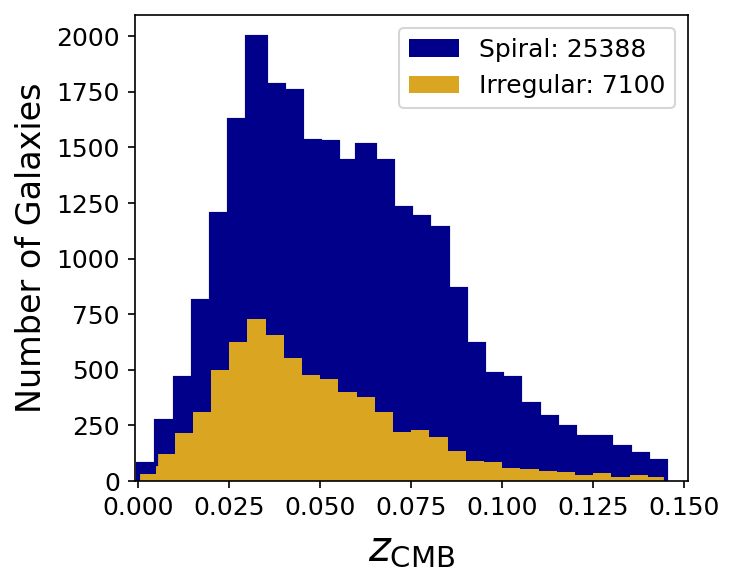

In [138]:
plt.figure(figsize=(5,4),tight_layout=True, dpi=150, facecolor='none')

# plt.hist(sgatab['Z_DESI_CMB'],
#          bins=np.arange(0, 0.175, 0.005), 
#          color='lightgray',
#          alpha=1,
#          label=f'Full Sample: {len(sgatab)}'
#         )

spirals = sgatab['MORPHTYPE']=='Spiral'
irregulars = sgatab['MORPHTYPE']=='Irregular'


plt.hist(sgatab['Z_DESI_CMB'][spirals],
         bins=np.arange(0, 0.15, 0.005),
         color='darkblue', alpha=1,
        label=f'Spiral: {np.sum(spirals)}')


plt.hist(sgatab['Z_DESI_CMB'][irregulars],
         bins=np.arange(0, 0.15, 0.005),
         color='goldenrod',
        label=f'Irregular: {np.sum(irregulars)}')


plt.hist(sgatab['Z_DESI_CMB'][spirals],
         bins=np.arange(0, 0.15, 0.005),
         color='darkblue', alpha=1, histtype='step', lw=2,
        )


# plt.hist(sgatab['Z_DESI_CMB'][outlier_boolean],
#          bins=np.arange(0, 0.175, 0.005), 
#          color='darkgray',
#          alpha=1,
#          label='Outliers'
#         )
plt.xlim(-0.001,0.151)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12)
plt.xlabel(r'$z_{\text{CMB}}$', fontsize=20)
plt.ylabel('Number of Galaxies', fontsize=16);

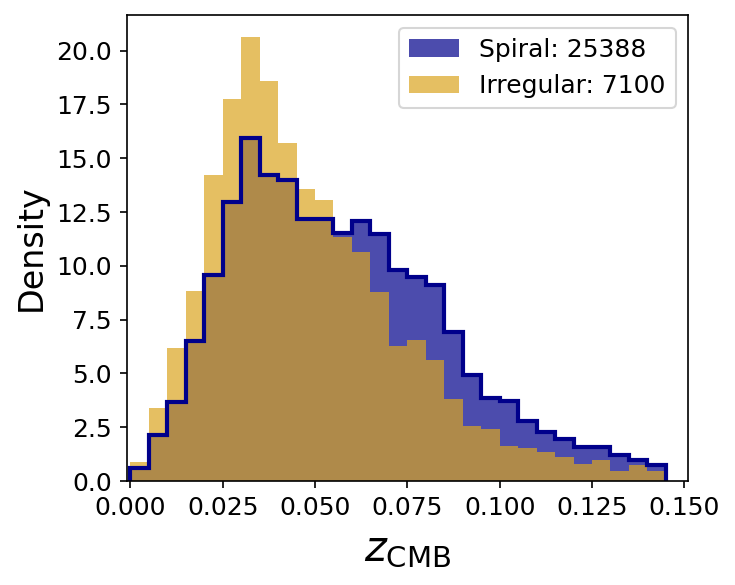

In [139]:
plt.figure(figsize=(5,4),tight_layout=True, dpi=150, facecolor='none')

# plt.hist(sgatab['Z_DESI_CMB'],
#          bins=np.arange(0, 0.175, 0.005), 
#          color='lightgray',
#          alpha=1,
#          label=f'Full Sample: {len(sgatab)}'
#         )

spirals = sgatab['MORPHTYPE']=='Spiral'
irregulars = sgatab['MORPHTYPE']=='Irregular'


plt.hist(sgatab['Z_DESI_CMB'][spirals],
         bins=np.arange(0, 0.15, 0.005),
         color='darkblue', alpha=0.7,
        label=f'Spiral: {np.sum(spirals)}', density=True)


plt.hist(sgatab['Z_DESI_CMB'][irregulars],
         bins=np.arange(0, 0.15, 0.005),
         color='goldenrod',
        label=f'Irregular: {np.sum(irregulars)}', density=True, alpha=0.7)


plt.hist(sgatab['Z_DESI_CMB'][spirals],
         bins=np.arange(0, 0.15, 0.005),
         color='darkblue', alpha=1, histtype='step', lw=2, density=True
        )


# plt.hist(sgatab['Z_DESI_CMB'][outlier_boolean],
#          bins=np.arange(0, 0.175, 0.005), 
#          color='darkgray',
#          alpha=1,
#          label='Outliers'
#         )
plt.xlim(-0.001,0.151)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12)
plt.xlabel(r'$z_{\text{CMB}}$', fontsize=20)
plt.ylabel('Density', fontsize=16);

# Photometric corrections

### Survey offsets

In [140]:
sys_corr, sys_corr_err = BASS_corr(sgatab['PHOTSYS'])

### MW dust corrections

In [141]:
# Import E(B-V) dust map
ebv_directory = '/global/cfs/cdirs/desicollab/users/rongpu/dust/desi_ebv/public_data/maps/'
# ebv_directory = '/Users/kdouglass/Documents/Research/data/DESI/'
ebv_filename = 'desi_dust_gr_512.fits'
ebv_map = Table.read(ebv_directory + ebv_filename)

In [142]:
MWdust_corr, MWdust_corr_err = MW_dust(sgatab['RA'], sgatab['DEC'], ebv_map)

/global/u1/s/sgmoore1/DESI_SGA/TF/TF_photoCorrect.py:90: UserWarning: Warning: converting a masked element to nan.
  EBV_err[i] = ebv_map['EBV_GR_ERR'][i_ebv]


In [143]:
# Flip NaN values to 0
MWdust_corr_err[np.isnan(MWdust_corr_err)] = 0

### Internal dust extinction correction

This is based off of a linear fit to ($b/a$, $m_r$), removing any correlation between $b/a$ and $m_r$.

In [144]:
# temp_infile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_z0p1_mcmc.pickle', 'rb')
temp_infile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_nokcorr_mcmc.pickle', 'rb')
# temp_infile = open('../loa_internalDust_nokcorr_mcmc.pickle', 'rb') #without k-corr
dust_mcmc_samples_r,_, dust_mcmc_samples_g,_, dust_mcmc_samples_z,_ = pickle.load(temp_infile)
temp_infile.close()

In [145]:
internalDust_coeffs_r = np.median(dust_mcmc_samples_r, axis=1)
internalDust_coeffs_g = np.median(dust_mcmc_samples_g, axis=1)
internalDust_coeffs_z = np.median(dust_mcmc_samples_z, axis=1)

internalDust_coeffs_err_r = np.zeros(len(internalDust_coeffs_r))
internalDust_coeffs_err_g = np.zeros(len(internalDust_coeffs_g))
internalDust_coeffs_err_z = np.zeros(len(internalDust_coeffs_z))

internalDust_coeffs_err_r[0] = np.std(dust_mcmc_samples_r[0][(-1.5 < dust_mcmc_samples_r[0]) & (dust_mcmc_samples_r[0] < 0)])
internalDust_coeffs_err_r[1] = np.std(dust_mcmc_samples_r[1][(0 < dust_mcmc_samples_r[1]) & (dust_mcmc_samples_r[1] < 1)])

internalDust_coeffs_err_g[0] = np.std(dust_mcmc_samples_g[0][(-1.5 < dust_mcmc_samples_g[0]) & (dust_mcmc_samples_g[0] < 0)])
internalDust_coeffs_err_g[1] = np.std(dust_mcmc_samples_g[1][(0 < dust_mcmc_samples_g[1]) & (dust_mcmc_samples_g[1] < 1)])

internalDust_coeffs_err_z[0] = np.std(dust_mcmc_samples_z[0][(-1.5 < dust_mcmc_samples_z[0]) & (dust_mcmc_samples_z[0] < 0)])
internalDust_coeffs_err_z[1] = np.std(dust_mcmc_samples_z[1][(0 < dust_mcmc_samples_z[1]) & (dust_mcmc_samples_z[1] < 1)])

In [146]:
internalDust_corr_r, internalDust_corr_err_r = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_r, 
                                                             internalDust_coeffs_err_r)

internalDust_corr_g, internalDust_corr_err_g = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_g, 
                                                             internalDust_coeffs_err_g)

internalDust_corr_z, internalDust_corr_err_z = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_z, 
                                                             internalDust_coeffs_err_z)

In [147]:
print(internalDust_coeffs_r[0], internalDust_coeffs_err_r[0])


-0.7649209228168957 0.2173486175169116


## Apply corrections

In [148]:
##### without k-correction, since we are calibrating in redshift bins

sgatab['G_MAG_SB26_CORR'] = sgatab['G_MAG_SB26'] - MWdust_corr[0] + sys_corr - internalDust_corr_g
sgatab['R_MAG_SB26_CORR'] = sgatab['R_MAG_SB26'] - MWdust_corr[1] + sys_corr - internalDust_corr_r
sgatab['Z_MAG_SB26_CORR'] = sgatab['Z_MAG_SB26'] - MWdust_corr[2] + sys_corr - internalDust_corr_z

In [149]:
sgatab['G_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['G_MAG_SB26_ERR']**2 + MWdust_corr_err[0]**2 + sys_corr_err**2 + internalDust_corr_err_g**2)
sgatab['R_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['R_MAG_SB26_ERR']**2 + MWdust_corr_err[1]**2 + sys_corr_err**2 + internalDust_corr_err_r**2)
sgatab['Z_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['Z_MAG_SB26_ERR']**2 + MWdust_corr_err[2]**2 + sys_corr_err**2 + internalDust_corr_err_z**2)

In [150]:
#### Add extra columns for Alex 

sgatab['R_MWDUST_CORR'] = MWdust_corr[1]
sgatab['R_SYS_CORR'] = sys_corr
sgatab['R_INTDUST_CORR'] = internalDust_corr_r

sgatab['MU_ZCMB'] = 5*np.log10(Planck18_h.comoving_distance(sgatab["Z_DESI_CMB"]).value * (1 + sgatab["Z_DESI"]))+25
sgatab['MU_ZCMB'][sgatab['Z_DESI_CMB']<0] = Planck18_h.distmod(sgatab['Z_DESI_CMB'][sgatab['Z_DESI_CMB']<0])

sgatab['R_ABSMAG_SB26'] = sgatab['R_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value
sgatab['G_ABSMAG_SB26'] = sgatab['G_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value
sgatab['Z_ABSMAG_SB26'] = sgatab['Z_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value

# sgatab['logV'] = np.log10(sgatab['V_0p4R26'])
# sgatab['logV_ERR'] = 0.434*sgatab['V_0p4R26_ERR']/sgatab['V_0p4R26']

sgatab['R_ABSMAG_SB26_CORR'] = sgatab['R_ABSMAG_SB26']
sgatab['R_ABSMAG_SB26_ERR'] = sgatab['R_MAG_SB26_ERR_CORR']
sgatab['R_ABSMAG_SB26_ERR_CORR'] = sgatab['R_MAG_SB26_ERR_CORR']

sgatab['G_ABSMAG_SB26_CORR'] = sgatab['G_ABSMAG_SB26']
sgatab['G_ABSMAG_SB26_ERR'] = sgatab['G_MAG_SB26_ERR_CORR']
sgatab['G_ABSMAG_SB26_ERR_CORR'] = sgatab['G_MAG_SB26_ERR_CORR']

sgatab['Z_ABSMAG_SB26_CORR'] = sgatab['Z_ABSMAG_SB26']
sgatab['Z_ABSMAG_SB26_ERR'] = sgatab['Z_MAG_SB26_ERR_CORR']
sgatab['Z_ABSMAG_SB26_ERR_CORR'] = sgatab['Z_MAG_SB26_ERR_CORR']


# sgatab.write('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/D2_TF_vrot_all_v5.fits', overwrite=True)

/tmp/ipykernel_539951/1172080999.py:7: RuntimeWarning: invalid value encountered in log10
  sgatab['MU_ZCMB'] = 5*np.log10(Planck18_h.comoving_distance(sgatab["Z_DESI_CMB"]).value * (1 + sgatab["Z_DESI"]))+25


# Redshift bins

Separate the galaxies into redshift bins of width 0.005, starting at a redshift of 0, so that we can fit an ellipse in each redshift bin.
The optimal scale for these ellipse was determined using the TF mocks to be 2.86.

In [151]:
zmin=0
# zmin = 0.03
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
binwidth=dz

In [152]:
for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.000    4 galaxies
 1  0.000 < z <= 0.005  207 galaxies
 2  0.005 < z <= 0.010  581 galaxies
 3  0.010 < z <= 0.015  864 galaxies
 4  0.015 < z <= 0.020  1339 galaxies
 5  0.020 < z <= 0.025  1923 galaxies
 6  0.025 < z <= 0.030  2478 galaxies
 7  0.030 < z <= 0.035  2930 galaxies
 8  0.035 < z <= 0.040  2627 galaxies
 9  0.040 < z <= 0.045  2468 galaxies
10  0.045 < z <= 0.050  2144 galaxies
11  0.050 < z <= 0.055  2136 galaxies
12  0.055 < z <= 0.060  1971 galaxies
13  0.060 < z <= 0.065  1995 galaxies
14  0.065 < z <= 0.070  1898 galaxies
15  0.070 < z <= 0.075  1572 galaxies
16  0.075 < z <= 0.080  1517 galaxies
17  0.080 < z <= 0.085  1429 galaxies
18  0.085 < z <= 0.090  1060 galaxies
19  0.090 < z <= 0.095  761 galaxies
20  0.095 < z <= 0.100  625 galaxies
21  z > 0.100  3049 galaxies


# Apply Cuts Suitable for Calibrating the TFR

Requirements:
* $10~\mathrm{km/s} < V_\mathrm{rot} < 1000~\mathrm{km/s}$ at $0.4R_{26}$
* $\Delta V/V_\mathrm{min} \leq 5$
* Passed visual inspection (both ours and John Lucey's)
* $i > 45^\circ$
* Spiral-type morphology
* Not an outlier (based on fitting an ellipse to the data)

The first 2.5 items have already been applied (our VI results have already been applied, but not John's).

In [153]:
def fit_ellipse(x,y, contam=0.05):
    X = np.vstack([x, y]).T
    ee = EllipticEnvelope(contamination=contam, random_state=0)
    ee.fit(X)
    return ee.location_, ee.covariance_

def plot_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """
    Draw a confidence ellipse from mean and covariance.
    n_std=2 ~ 95% for 2D
    """
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))

    width, height = 2 * n_std * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        **kwargs
    )
    ax.add_patch(ellipse)

def ellipse_boolean(x, y, n_std, mean=None, cov=None, contam=0.05):

    X = np.vstack([x, y]).T

    if mean is None or cov is None:
        ee = EllipticEnvelope(contamination=contam, random_state=0)
        ee.fit(X)
        mahal_sq = ee.mahalanobis(X)
    else:
        cov_inv = np.linalg.inv(cov)
        diff = X - mean
        mahal_sq = np.sum((diff @ cov_inv) * diff, axis=1)

    return mahal_sq > n_std**2

## Fit an ellipse in each redshift bin

We will separately fit the ellipses to the spiral and irregular populations

In [154]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)
# cosmo = DESI()

# sgatab['MU_ZCMB'] = cosmo.distmod(sgatab['Z_DESI_CMB'])

# sgatab['MU_ZCMB'] = 5*np.log10(cosmo.comoving_distance(sgatab["Z_DESI_CMB"]).value * (1 + sgatab["Z_DESI"]))+25

sgatab['R_ABSMAG_SB26'] = sgatab['R_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value

In [155]:
zmin=0.01
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)
zc = 0.5*dz + zbins[:-1]
zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
binwidth=dz

mu_zc = cosmo.distmod(zc)

In [156]:
# sigma = 2.5
sigma = 2.86
mu_x = []
mu_y = []
cov_xx = []
cov_xy = []
cov_yx = []
cov_yy = []
z_min = []
# # fit the lowest bin in absolute magnitude space (if we don't want to start at zero)
# z_min.append(0)
# x = np.log10(sgatab['V_0p4R26'][zbin_indices==0])
# y = sgatab['R_ABSMAG_SB26'][zbin_indices==0]
# ellipse_mean, ellipse_cov = fit_ellipse(x,y)
# # print(ellipse_mean, ellipse_cov)
# mu_x.append(ellipse_mean[0])
# mu_y.append(ellipse_mean[1])
# cov_xx.append(ellipse_cov[0][0]) 
# cov_xy.append(ellipse_cov[0][1]) 
# cov_yx.append(ellipse_cov[1][0]) 
# cov_yy.append(ellipse_cov[1][1]) 

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)

for i in range(1,len(zbins)):
    z_min.append(0.005*(i-1))
    x = sgatab['logV_SBcorr'][zbin_indices==i]
    y = sgatab['R_MAG_SB26_CORR'][zbin_indices==i]

    ellipse_mean, ellipse_cov = fit_ellipse(x,y, contam=0.05)
    # print(ellipse_mean, ellipse_cov)
    mu_x.append(ellipse_mean[0])
    mu_y.append(ellipse_mean[1])
    cov_xx.append(ellipse_cov[0][0]) 
    cov_xy.append(ellipse_cov[0][1]) 
    cov_yx.append(ellipse_cov[1][0]) 
    cov_yy.append(ellipse_cov[1][1]) 

# # ## fit the highest bin in absolute magnitude space (if we care about above z=0.1)
# i=len(zbins)
# z_min.append(zmax)
# x = np.log10(sgatab['V_0p4R26'][zbin_indices==0])
# y = sgatab['R_ABSMAG_SB26'][zbin_indices==0]
# ellipse_mean, ellipse_cov = fit_ellipse(x,y)
# # print(ellipse_mean, ellipse_cov)
# mu_x.append(ellipse_mean[0])
# mu_y.append(ellipse_mean[1])
# cov_xx.append(ellipse_cov[0][0]) 
# cov_xy.append(ellipse_cov[0][1]) 
# cov_yx.append(ellipse_cov[1][0]) 
# cov_yy.append(ellipse_cov[1][1]) 

In [157]:
ellipse_params = Table([mu_x, mu_y, cov_xx, cov_xy, cov_yx, cov_yy],
    names=['MU_X', 'MU_Y', 'COV_XX', 'COV_XY', 'COV_YX', 'COV_YY'])
# ellipse_params.write(f'/global/homes/s/sgmoore1/DESI_SGA/TF/Y3/v3/TF_Y3_ellipse_fit_mr_0p01-0p1.fits')

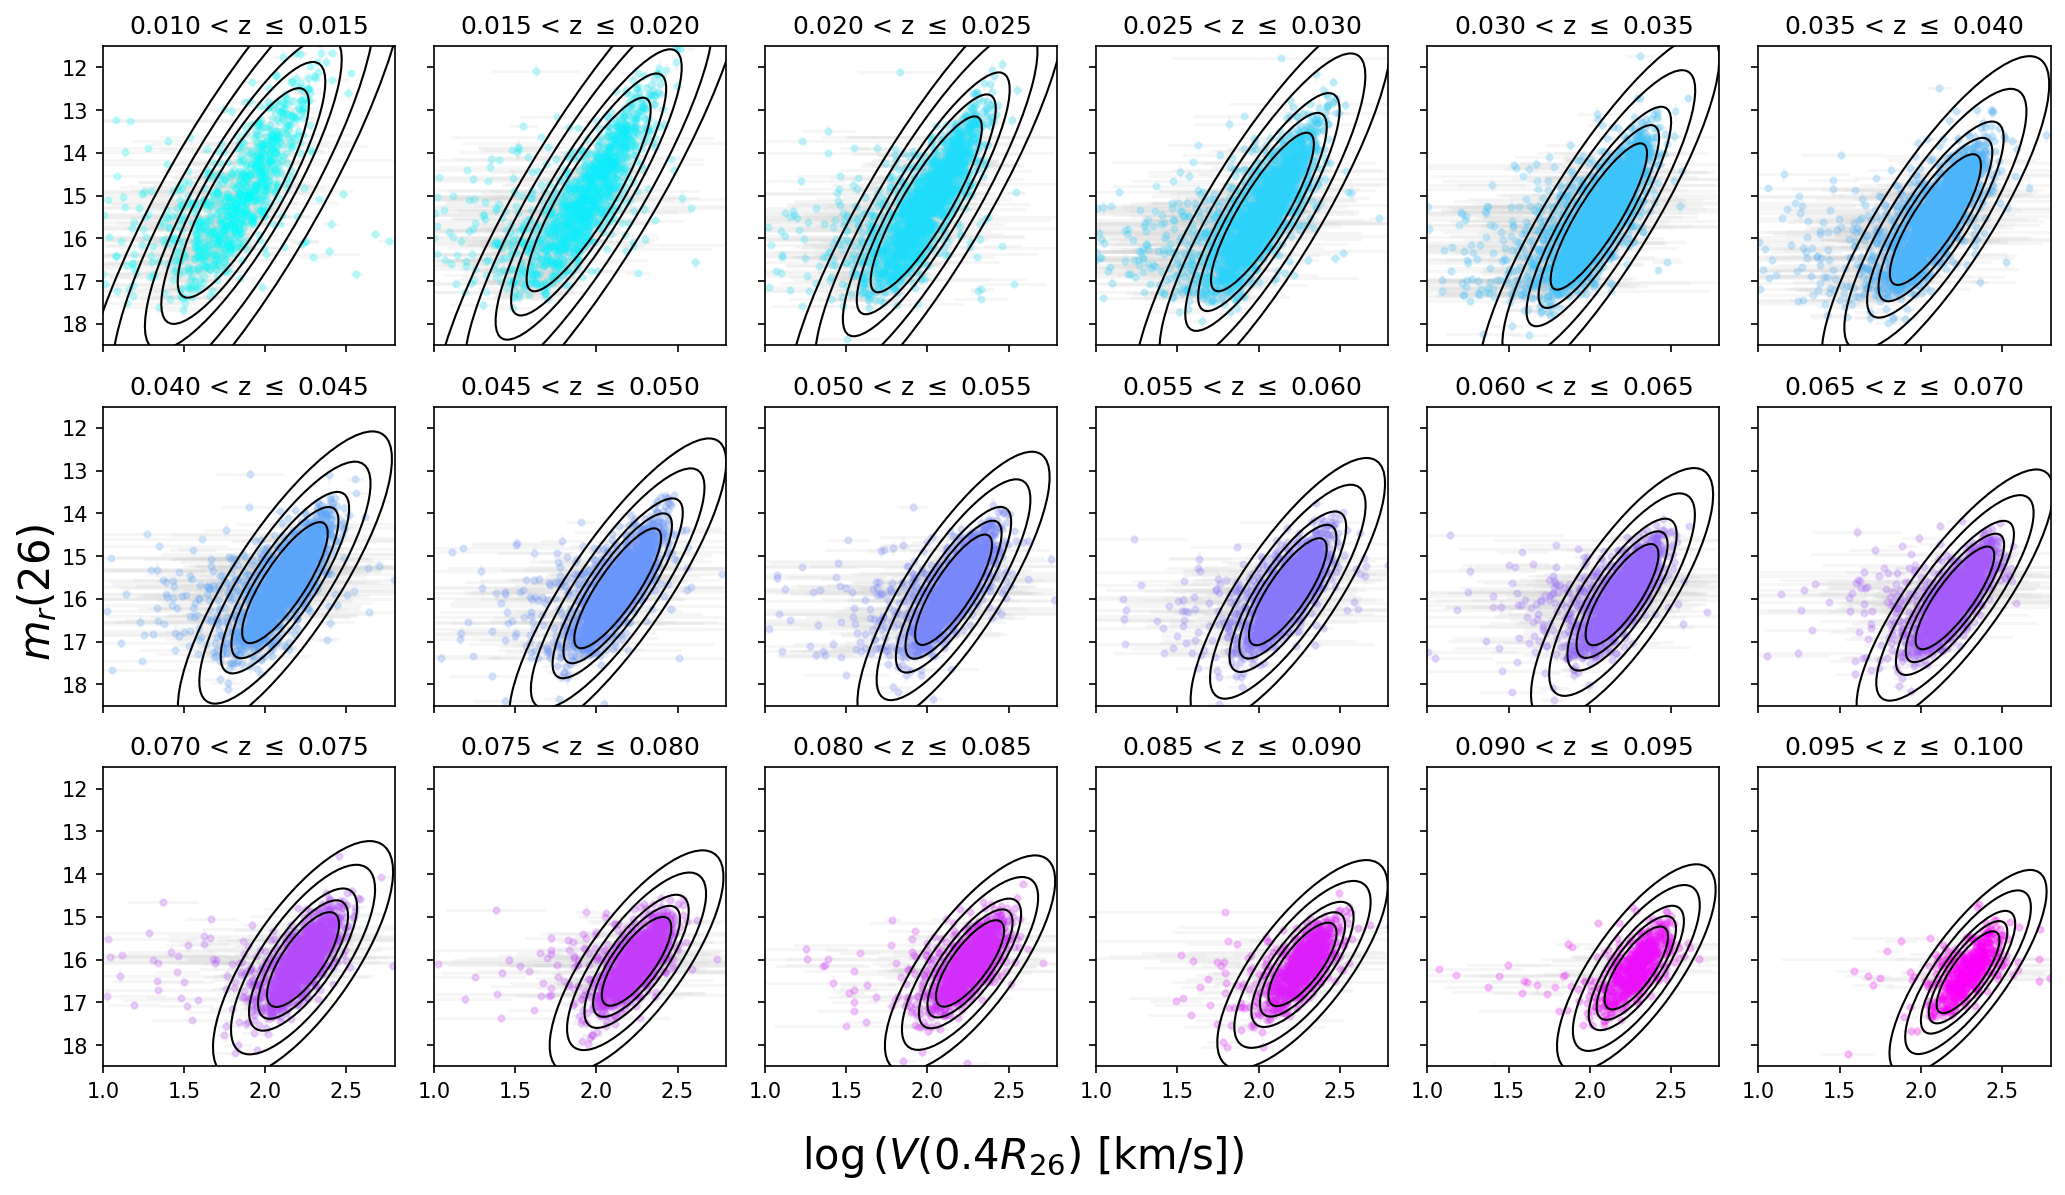

In [158]:
ncols=6
zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)
# fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
m = len(mu_x)
color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/ncols)
    col = i%ncols
    
    eb = axs[row,col].errorbar(sgatab['logV_SBcorr'][zbin_indices==i+1],#+1], 
                               sgatab['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
                               xerr=sgatab['logV_SBcorr_err'][zbin_indices==i+1],#+1], 
                               yerr=sgatab['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
                               fmt='.', color=c, ecolor='lightgray', alpha=0.2)
    # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 5, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 2.5, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 3, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 4, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 2, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)

    
    # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
    axs[row,col].set(xlim=[1, 2.8], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
fig.supylabel(r'$m_r (26)$', fontsize=20);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/v7_bin_ellipses_prefit.png', 
#             dpi=150, 
#             facecolor='none')


In [159]:
# sigma=2.5

zmin=0.01
# zmin = 0.03
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)

outlier_boolean = np.zeros(len(sgatab), dtype=bool)

# ## do the lowest and highest bins separately since they are in absmag space
bin_mask = (zbin_indices == 0)
x = sgatab['logV_SBcorr'][bin_mask]
y = sgatab['R_ABSMAG_SB26'][bin_mask]
outlier_bin = ellipse_boolean(x, y, sigma)
outlier_boolean[bin_mask] = outlier_bin

for i in range(1,len(zbins)):
    bin_mask = (zbin_indices == i)

    x = sgatab['logV_SBcorr'][bin_mask]
    y = sgatab['R_MAG_SB26_CORR'][bin_mask]

    # Outliers *within this bin*
    outlier_bin = ellipse_boolean(x, y, sigma)

    # Write results back into global array
    outlier_boolean[bin_mask] = outlier_bin

bin_mask = (zbin_indices == len(zbins))
x = sgatab['logV_SBcorr'][bin_mask]
y = sgatab['R_ABSMAG_SB26'][bin_mask]
outlier_bin = ellipse_boolean(x, y, sigma)
outlier_boolean[bin_mask] = outlier_bin

print(np.sum(outlier_boolean), len(outlier_boolean), np.sum(outlier_boolean)/len(outlier_boolean))

3255 35578 0.09148912249142728


In [161]:
# zmin=0.01
zmin = 0.02
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'][~outlier_boolean], zbins, right=True)

binwidth=dz

for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.020  2649 galaxies
 1  0.020 < z <= 0.025  1732 galaxies
 2  0.025 < z <= 0.030  2212 galaxies
 3  0.030 < z <= 0.035  2616 galaxies
 4  0.035 < z <= 0.040  2365 galaxies
 5  0.040 < z <= 0.045  2251 galaxies
 6  0.045 < z <= 0.050  1968 galaxies
 7  0.050 < z <= 0.055  1938 galaxies
 8  0.055 < z <= 0.060  1801 galaxies
 9  0.060 < z <= 0.065  1814 galaxies
10  0.065 < z <= 0.070  1749 galaxies
11  0.070 < z <= 0.075  1462 galaxies
12  0.075 < z <= 0.080  1401 galaxies
13  0.080 < z <= 0.085  1314 galaxies
14  0.085 < z <= 0.090  980 galaxies
15  0.090 < z <= 0.095  702 galaxies
16  0.095 < z <= 0.100  561 galaxies
17  z > 0.100  2808 galaxies


## Apply other cuts

In [162]:
#- Inclination cut
cosi2 = (sgatab['BA']**2 - q0**2) / (1 - q0**2)
i_min = 45. * u.degree
cosi2_max = np.cos(i_min)**2
is_good_incl = cosi2 < cosi2_max

#- Morphology cut: only ML
is_good_morph_ML = np.zeros_like(is_good_incl, dtype=bool)
is_irregular_ML = np.zeros_like(is_good_incl, dtype=bool)
for i in range(len(sgatab)):
    if sgatab['MORPHTYPE'][i] == 'Spiral':
        is_good_morph_ML[i] = True
    elif sgatab['MORPHTYPE'][i] == 'Irregular':
        is_irregular_ML[i] = True

#- John's VI
is_good_John = sgatab['JOHN_VI'].mask

#- Combine selections:
is_good_sga = is_good_incl & is_good_morph_ML & is_good_John & ~outlier_boolean
# is_good_sga_irregular = is_good_incl & is_irregular_ML & is_good_John & ~outlier_boolean_irr

In [163]:
# is_faceon = (sgatab['BA']**2 - q0**2) / (1 - q0**2) > np.cos(25. * u.degree)**2

In [164]:
# sgatab['V_0p4R26', 'BA', 'V_0p4R26_ERR', 'R_ABSMAG_SB26', 'Z_DESI'][is_faceon]

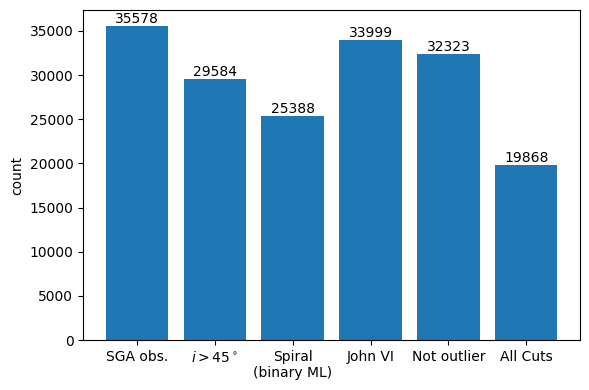

In [165]:
data = {
    'SGA obs.' : len(sgatab),
    # r'$10 < V_\mathrm{rot} < 1000$' : np.sum(is_good_velo),
    # r'$\Delta V/V_\mathrm{min}>5$' : np.sum(is_good_dv),
    r'$i > 45^\circ$' : np.sum(is_good_incl), 
    # 'Spiral' : np.sum(is_good_morph),
    'Spiral\n(binary ML)' : np.sum(is_good_morph_ML),
    'John VI' : np.sum(is_good_John), 
    # 'Not dwarf' : np.sum(~dwarf_boolean), 
    'Not outlier' : np.sum(~outlier_boolean), 
    'All Cuts' : np.sum(is_good_sga), 
    # 'All Cuts\n(binary ML)' : np.sum(is_good_sga_ML)
}
names = list(data.keys())
values = list(data.values())

fig, ax = plt.subplots(1, 1, figsize=(6,4), tight_layout=True)
bars = ax.bar(names, values, color='tab:blue')
ax.bar_label(bars, fmt='%d')
ax.set(ylabel='count');#, yscale='log', ylim=[1e3,1.2e4]);

# fig.savefig('../../Figures/Y1/TF_Y1_SGA_Vrot_cuts.png', dpi=150, facecolor='none');

In [173]:
spiral_boolean = sgatab['MORPHTYPE'] == 'Spiral'
irregular_boolean = sgatab['MORPHTYPE'] == 'Irregular'
# other_boolean = sgatab['MORPHTYPE'] == 'Other'

VI_boolean = sgatab['JOHN_VI'].mask

morph_boolean = (spiral_boolean | irregular_boolean) & VI_boolean

redshift_boolean = (sgatab['Z_DESI_CMB'] > 0.02) & (sgatab['Z_DESI_CMB'] < 0.10)

In [174]:
sgatab['GOOD_MORPH'] = morph_boolean

print(sum(outlier_boolean), 'outliers')
print(sum(~outlier_boolean), 'non-outliers')
print('-----------')
print(np.sum(morph_boolean), 'spirals & irregulars that pass VI')
print(np.sum(morph_boolean & outlier_boolean), 'outliers')
print(np.sum(morph_boolean & ~outlier_boolean), 'non-outliers')

3255 outliers
32323 non-outliers
-----------
31368 spirals & irregulars that pass VI
2384 outliers
28984 non-outliers


In [175]:
# # Create a single column to denote which objects should be used for cosmological analysis
# True if the object is not an outlier according to the appropriate fit
# main_boolean = (
#     (spiral_boolean & ~outlier_boolean) |
#     (irregular_boolean & ~outlier_boolean_irr)
# ) & VI_boolean

sgatab['MAIN'] = morph_boolean & ~outlier_boolean

In [176]:
# ### Denote which objects are used for either the spiral or irregular calibrations

sgatab['CAL'] = np.zeros(len(sgatab))
sgatab['CAL'][is_good_sga & redshift_boolean] = 1
# sgatab['CAL'][is_good_sga_irregular & redshift_boolean] = 2

In [177]:
np.sum(sgatab['MAIN'])

28984

In [178]:
sgatab_sel = sgatab[is_good_sga]
# irregular_sel = sgatab[is_good_sga_irregular]
zbin_indices = np.digitize(sgatab_sel['Z_DESI_CMB'], zbins, right=True)
# zbin_indices_irr = np.digitize(irregular_sel['Z_DESI_CMB'], zbins, right=True)

In [179]:
for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.020  1277 galaxies
 1  0.020 < z <= 0.025  942 galaxies
 2  0.025 < z <= 0.030  1263 galaxies
 3  0.030 < z <= 0.035  1527 galaxies
 4  0.035 < z <= 0.040  1339 galaxies
 5  0.040 < z <= 0.045  1313 galaxies
 6  0.045 < z <= 0.050  1166 galaxies
 7  0.050 < z <= 0.055  1179 galaxies
 8  0.055 < z <= 0.060  1113 galaxies
 9  0.060 < z <= 0.065  1164 galaxies
10  0.065 < z <= 0.070  1125 galaxies
11  0.070 < z <= 0.075  976 galaxies
12  0.075 < z <= 0.080  924 galaxies
13  0.080 < z <= 0.085  927 galaxies
14  0.085 < z <= 0.090  696 galaxies
15  0.090 < z <= 0.095  503 galaxies
16  0.095 < z <= 0.100  377 galaxies
17  z > 0.100  2057 galaxies


In [180]:
_, counts = np.unique(zbin_indices, return_counts=True)

print(np.min(counts[1:-1]), np.max(counts[1:-1]))

377 1527


# Build the Calibration Table of SGA Galaxies

In [181]:
sgatab_sel['Z_BIN_IDX'] = zbin_indices

no_use = (zbin_indices == 0) | (zbin_indices == len(zbins))
caltab = sgatab_sel[~no_use]

rejtab = sgatab_sel[no_use]

# caltab.write('SGA-2020_iron_Vrot_cluster_calib_z0p1_Anthony2_dVsys.fits', overwrite=True)
caltab[['Z_BIN_IDX', 'Z_DESI_CMB', 'SGA_ID', 'R_MAG_SB26_CORR', 'R_MAG_SB26_ERR_CORR', 'V_0p4R26', 'V_0p4R26_ERR', 'logV_SBcorr', 'logV_SBcorr_err']]

Z_BIN_IDX,Z_DESI_CMB,SGA_ID,R_MAG_SB26_CORR,R_MAG_SB26_ERR_CORR,V_0p4R26,V_0p4R26_ERR,logV_SBcorr,logV_SBcorr_err
int64,float64,float64,float64,float64,float64,float64,float64,float64
16,0.09583935447193448,32.0,15.475734646579623,0.13234981016091993,242.31732801933134,18.2834008394214,2.387199814952756,0.03295926985314505
13,0.08162267561348635,38.0,16.943537400959432,0.13361490427350428,122.10002350181783,11.575073994874746,2.089558885184187,0.04141340080774459
16,0.09910672096429418,53.0,16.343658835513892,0.09388462142280865,237.8295282238147,19.144538438345666,2.379541032360435,0.03520011751754765
6,0.045082555650847844,55.0,17.150481296321377,0.10846211329218215,82.16642593696996,6.494247769763402,1.9138880666332518,0.03423874653893916
6,0.04576245512250576,63.0,16.379688388854266,0.16325676928664218,88.93146709845647,5.535181647491917,1.948469186144023,0.026976144512041254
4,0.039043626012540855,74.0,16.0340261644125,0.20054971863002308,92.43620953305918,10.018045188842146,1.9649419656619547,0.04693863163470957
8,0.055628906754008556,76.0,16.216555037330835,0.11055099423961041,131.82776915777,12.138195719213863,2.1203295457353946,0.03999075518816493
15,0.09120767170112742,117.0,16.15585258799605,0.13854330442033155,183.08805286733877,14.0547976285255,2.265192358420596,0.03351094481676575
5,0.04427201534577052,149.0,15.764151984307357,0.08336590469221816,166.06262670686112,17.77289747783132,2.219765776731953,0.046394867172323745


# Apply the Joint TFR Fit

In [182]:
#- Extract successful clusters
_zbin_ids = np.unique(caltab['Z_BIN_IDX'])
m = len(_zbin_ids)

#- Pack the results into arrays data and cov.
logV, logV_err = [], []
mag, mag_err = [], []
weights = []

logV0 = np.median(caltab['logV_SBcorr'])
print('logV0 =', logV0)

#- Loop over the redshift bins
for k, _zbin_id in enumerate(_zbin_ids):
    select_zbin = np.isin(caltab['Z_BIN_IDX'], _zbin_id)
    logV.append(caltab['logV_SBcorr'][select_zbin] - logV0)
    logV_err.append(caltab['logV_SBcorr_err'][select_zbin])
    mag.append(caltab['R_MAG_SB26_CORR'][select_zbin])
    mag_err.append(caltab['R_MAG_SB26_ERR_CORR'][select_zbin])
    # weights.append(np.array(1/caltab['MAX_VOL_FRAC'][select_zbin]))
    weights.append(np.array(1))

logV0 = 2.173430622962117


## Multiline Fit using HyperFit

In [184]:
bounds = [[-20, 0]]                    # Bounds on a (slope)
bounds += m*[(-20, 20)]                # Bounds on b (intercepts: z-bins)
bounds += [(0,5)]                      # Bounds on sigma

results = hyperfit_line_multi(logV, mag, logV_err, mag_err, bounds, weights=weights, scatter=1)

a, b, sig_tfr, cov_tfr, tfr_mcmc_samples, hf_tfr = results

 message: Optimization terminated successfully.
 success: True
     fun: -36444.93747617603
       x: [-6.668e+00  1.406e+01 ...  1.711e+01  3.478e-01]
     nit: 221
    nfev: 60111
     jac: [ 6.330e-02  1.084e-01 ... -1.113e-01 -1.091e-01]
Ndim: 18 16


100%|██████████| 1000/1000 [01:18<00:00, 12.68it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [72.32347044 73.50538944 72.84690642 75.19782441 77.37559841 76.44729531
 76.77231546 74.52275974 72.48671377 77.62315101 66.42479288 73.80918675
 77.73269347 79.18005989 81.45783475 75.09021675 75.96812503 77.59941356] / 4072.8917374049056


100%|██████████| 1000/1000 [01:18<00:00, 12.66it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [101.50505393 104.08242111  98.06910387 106.19831484 106.0773254
  98.25230102  99.13188047 104.17284271  95.87106674 106.02462785
 100.35905091 103.44412859  99.3834929   93.49136288 105.93874719
 108.0696934  102.67823582 100.49508334] / 5403.4846700323515


...

Niterations/Max Iterations:  12000 / 100000
Integrated ACT/Min Convergence Iterations:  [186.72385557 224.5164336  191.28098927 199.06028767 186.37225698
 191.98924928 185.16507105 178.84002435 181.13889736 194.82397134
 214.76646017 188.34665942 197.59258696 188.61656044 206.97817364
 181.59733538 188.3617548  181.46072133] / 11225.821679906665


100%|██████████| 1000/1000 [01:20<00:00, 12.35it/s]


Niterations/Max Iterations:  13000 / 100000
Integrated ACT/Min Convergence Iterations:  [186.36288637 224.96525732 198.9197549  205.31517556 198.24422086
 191.97921119 185.54207655 173.22225483 187.55627998 196.03024844
 227.70321453 197.84207019 192.31324549 202.72745919 209.21074778
 183.90061657 204.15200355 178.63645295] / 11385.160726272574


100%|██████████| 1000/1000 [01:23<00:00, 12.04it/s]


Niterations/Max Iterations:  14000 / 100000
Integrated ACT/Min Convergence Iterations:  [188.07430629 220.01654161 193.08725902 209.52466808 205.37388531
 198.99711891 187.19364262 177.66514913 192.39406458 196.21191259
 224.31629083 200.35869353 198.02485301 205.46705461 208.99379111
 181.74767668 204.2498238  186.81598789] / 11215.814541468242


In [185]:
temp_outfile = open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_loa_jointTFR_ellipse_v6a_zmin0p02.pickle', 
                    'wb')
pickle.dump((cov_tfr, tfr_mcmc_samples, logV0, zmin, zmax, dz, zbins), temp_outfile)
temp_outfile.close()

In [186]:
# with open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_loa_jointTFR_ellipse_v3.pickle', 'rb') as f:
#     cov_tfr_saved, tfr_mcmc_samples_saved, logV0_saved, zmin_saved, zmax_saved, dz_saved, zbins_saved = pickle.load(f)

In [187]:
# with open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_loa_jointTFR_ellipse_v6a_zmin0p03.pickle', 'rb') as f:
#     cov_tfr, tfr_mcmc_samples, logV0, zmin, zmax, dz, zbins = pickle.load(f)

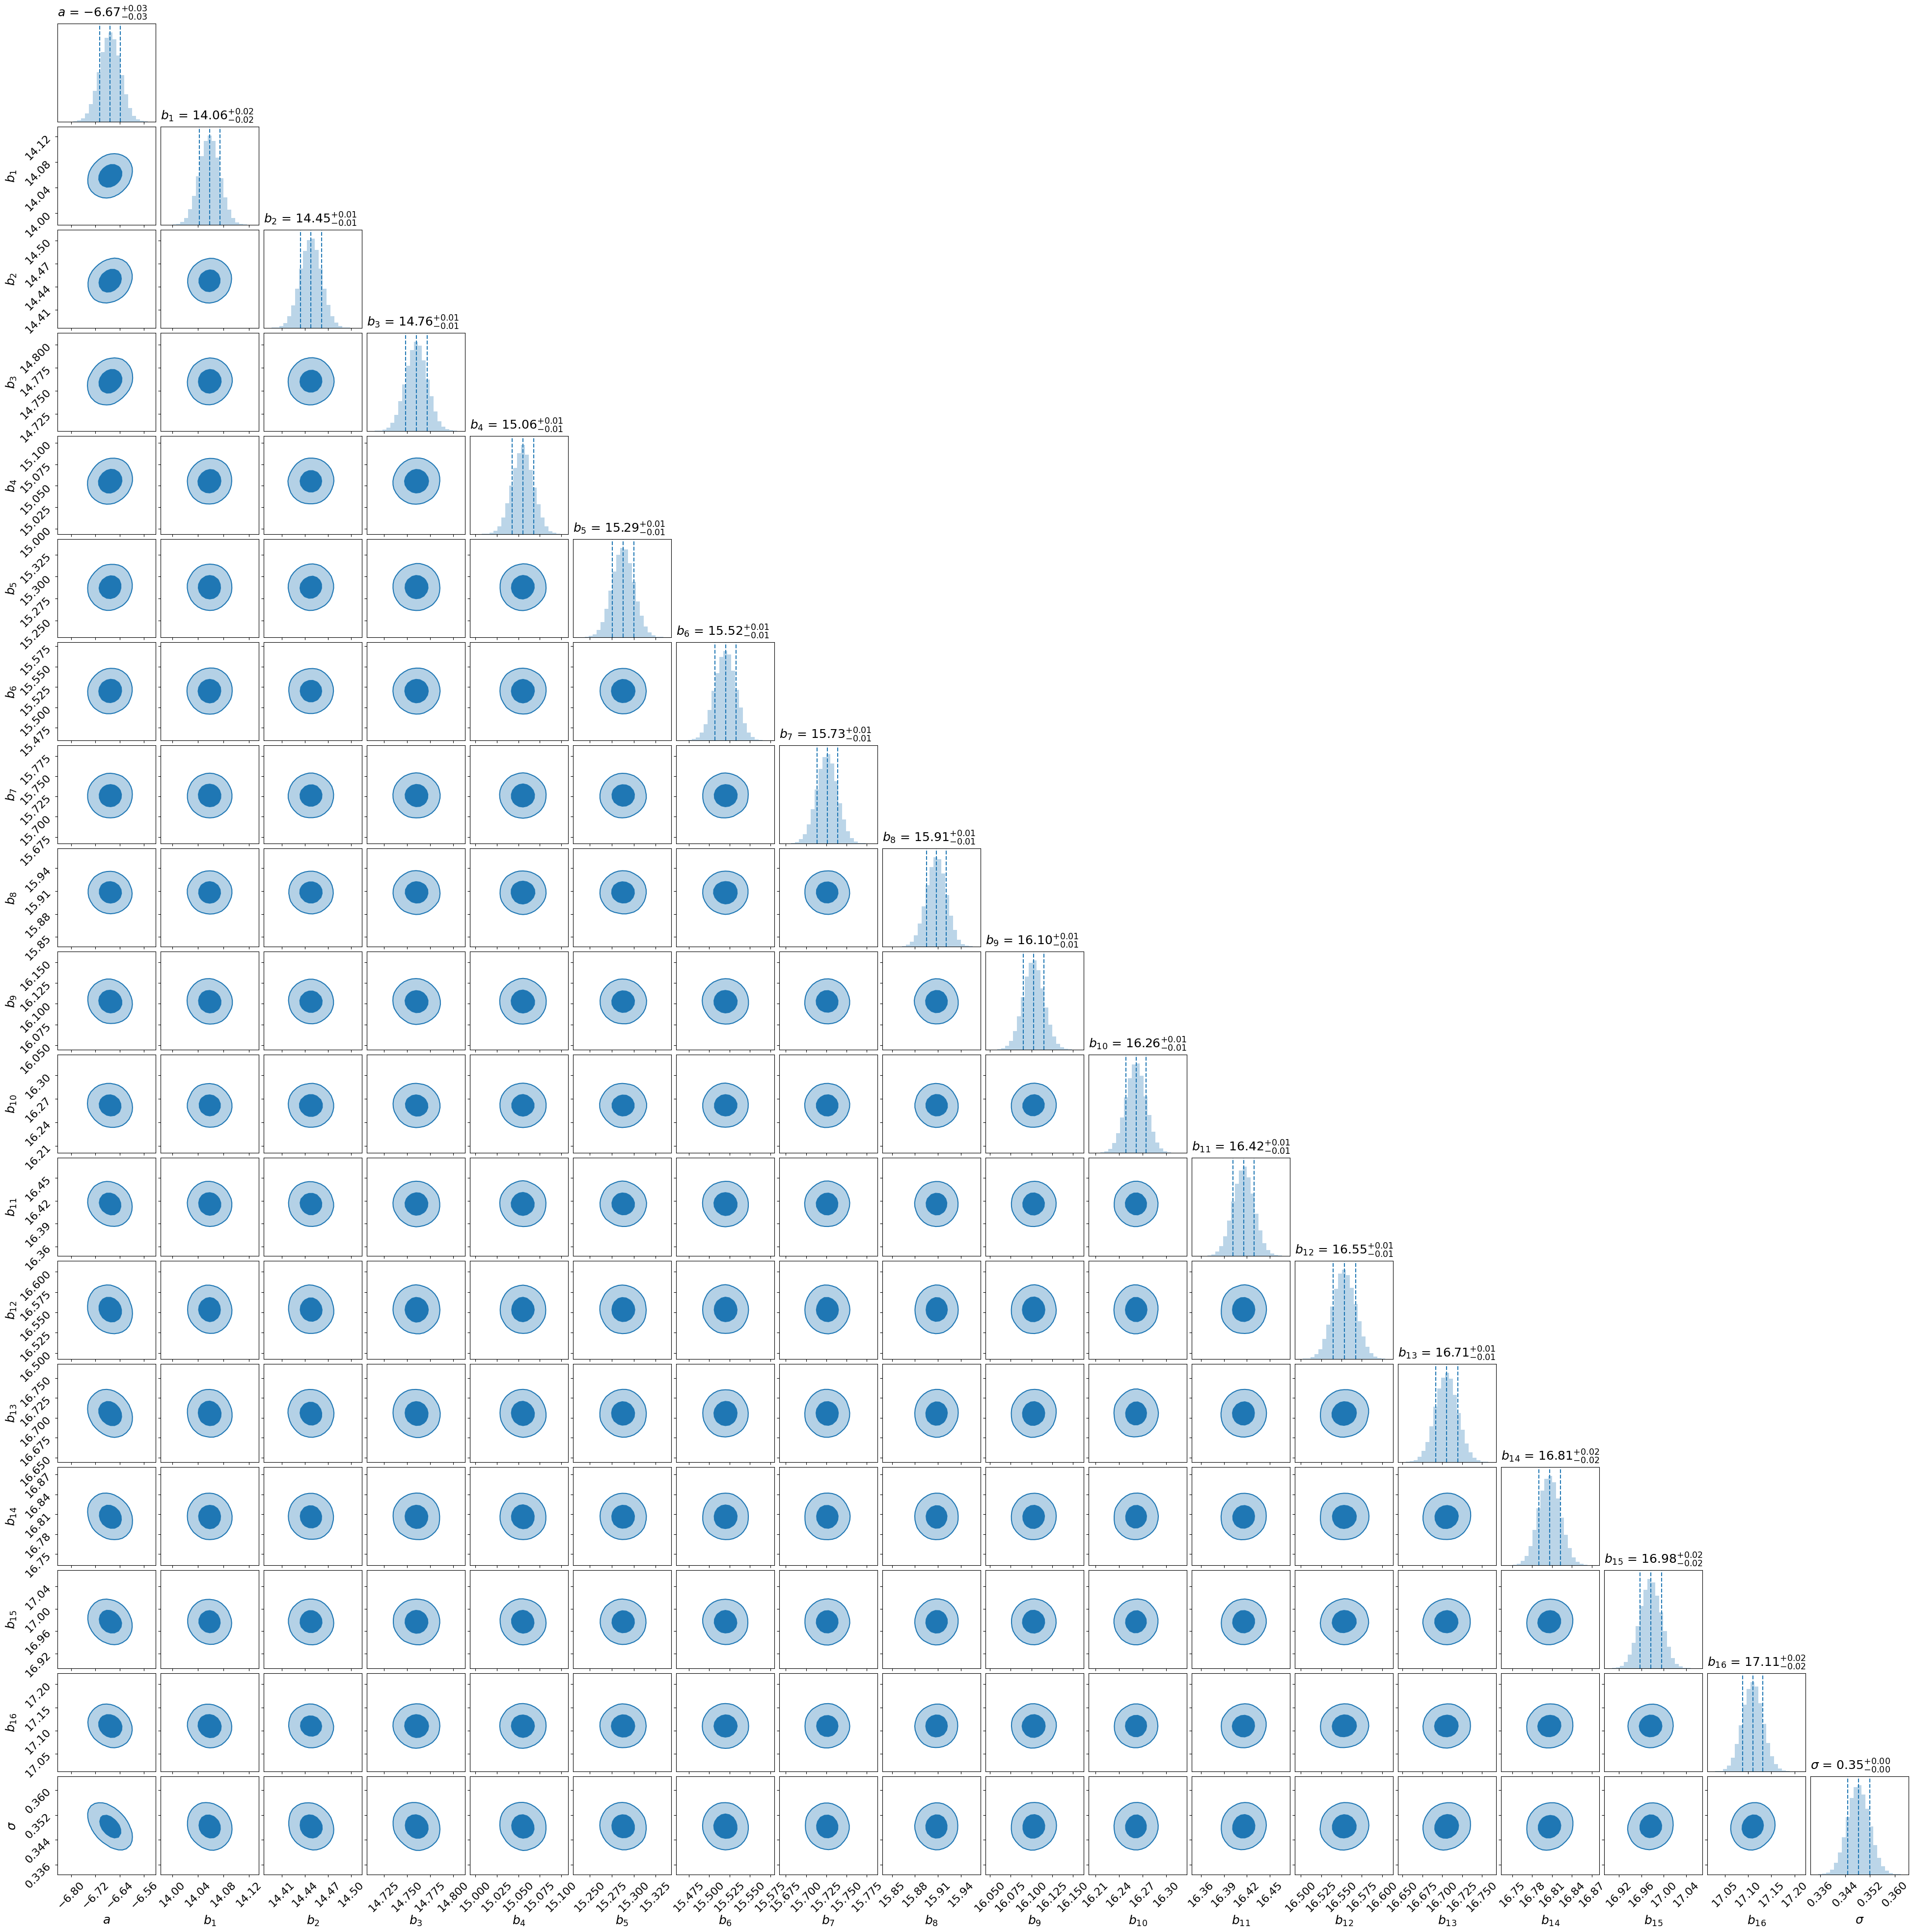

In [188]:
labels  = ['$a$']
labels += [f'$b_{{ {k+1} }}$' for k in np.arange(m)]
labels += [r'$\sigma$'] #+ [rf'$\sigma_{k}$' for k in np.arange(m)]

fig = corner(tfr_mcmc_samples.T, bins=25, smooth=1,
#              range=[[1.9, 2.4], [0.75, 1.1], [0.1, 0.3]],   # Range for a, b, sigma. Adjust as needed.
             labels=labels,
             label_kwargs={'fontsize':18},
             labelpad=0.1,
             levels=(1-np.exp(-0.5), 1-np.exp(-2)),
             quantiles=[0.16, 0.5, 0.84],
             color='tab:blue',
             hist_kwargs={'histtype':'stepfilled', 'alpha':0.3},
             plot_datapoints=False,
             fill_contours=True,
             show_titles=True,
             title_kwargs={"fontsize": 18, 'loc':'left', 'pad':10});

for ax in fig.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=16)

# fig.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_cornerplot_v3.png',
#     dpi=150,
#     bbox_inches='tight',
#     pad_inches=0.2,
#     facecolor='none'
# )

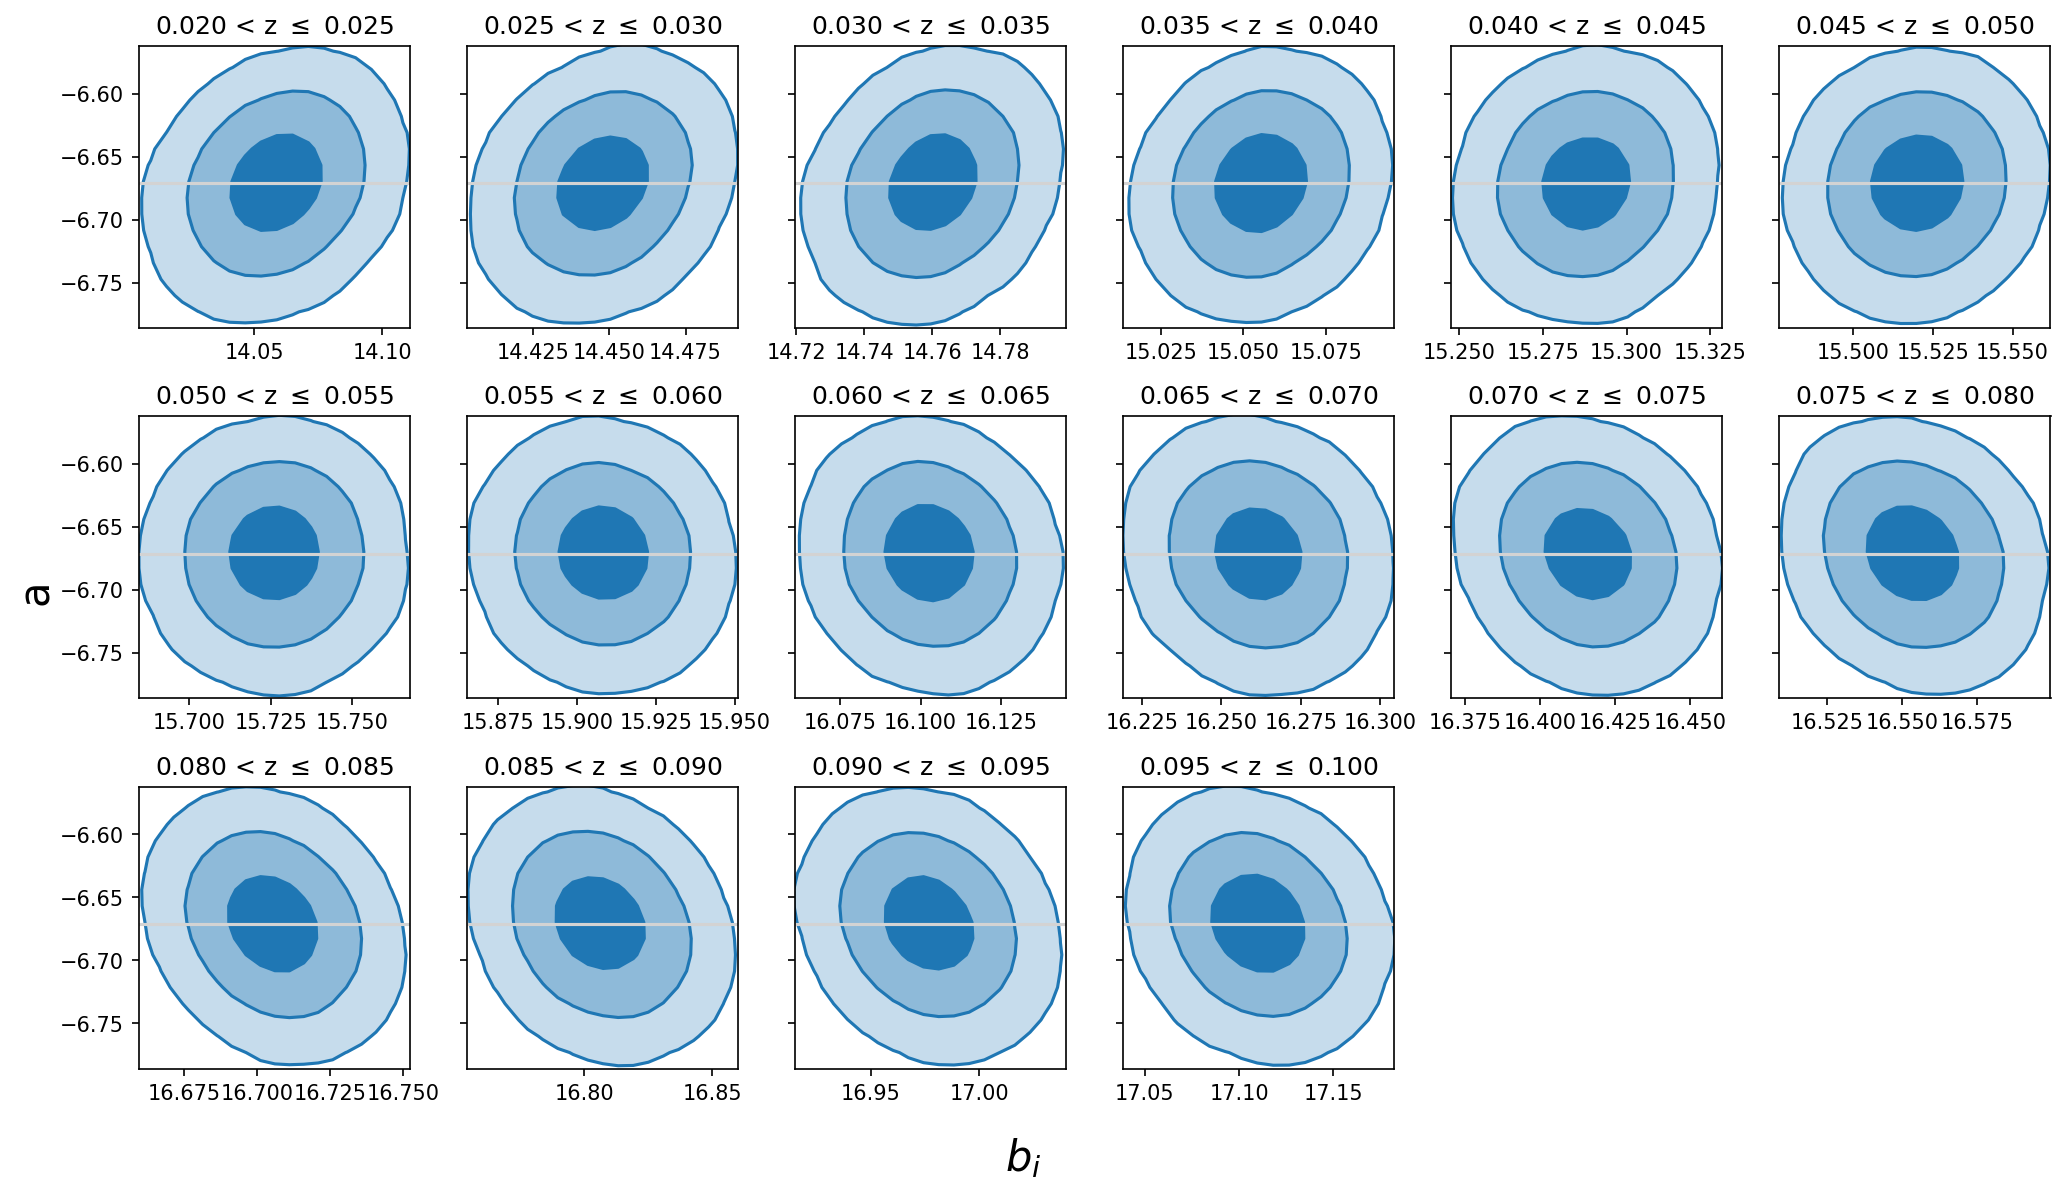

In [189]:
samples = tfr_mcmc_samples.T
a = samples[:, 0]
b_vals = samples[:, 1:-1]
n_b = b_vals.shape[1]
ncols = 6
nrows = 3
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=False, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)

axs = np.array(axs).reshape(-1)

for i in range(n_b):
    ax = axs[i]

    hist2d(
        b_vals[:, i],
        a,
        ax=ax,
        bins=25,
        smooth=1,
        levels=(1-np.exp(-0.5), 1-np.exp(-2), 1-np.exp(-4.5)),
        plot_datapoints=False,
        fill_contours=True,
        color='tab:blue'
    )
    ax.axhline(np.median(a), color='lightgray')

    ax.set(
        xlim = np.percentile(b_vals[:, i], [0.05,99.95]),
        ylim = np.percentile(a, [0.05,99.95]),
        title=f'{zbins[i]:.3f} < z $\\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}'
    )

    # if i % ncols == 0:
    #     ax.set_ylabel(f'$b_{{{i+1}}}$', fontsize=14)
    # if i >= (nrows-1)*ncols:
    #     ax.set_xlabel('$a$', fontsize=14)


# turn off unused axes
for j in range(n_b, len(axs)):
    axs[j].axis('off')

fig.supxlabel(r'$b_i$', fontsize=20)
fig.supylabel('a', fontsize=20)

plt.tight_layout()
# plt.show()

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/Y3_v2_fit_contours.png', 
#             dpi=150, 
#             facecolor='none')


# Plot the HyperFit Results

In [190]:
sigma_mcmc = np.percentile(tfr_mcmc_samples[-1], [16., 50., 84.])
a_mcmc = np.percentile(tfr_mcmc_samples[0], [16., 50., 84])
b_mcmc = []
# for k in range(1, m+2):
for k in range(1, m+1):
    b_mcmc.append(np.percentile(tfr_mcmc_samples[k], [16., 50., 84.]))
b_mcmc = np.asarray(b_mcmc)

In [191]:
i=0

while i < len(tfr_mcmc_samples):
    print(f'{np.mean(tfr_mcmc_samples[i]):.4f}, {np.sqrt(cov_tfr[i,i]):.4f};')
    i+=1

-6.6714, 0.0342;
14.0585, 0.0162;
14.4479, 0.0137;
14.7602, 0.0119;
15.0553, 0.0125;
15.2880, 0.0124;
15.5200, 0.0131;
15.7261, 0.0128;
15.9082, 0.0131;
16.1027, 0.0126;
16.2617, 0.0131;
16.4158, 0.0138;
16.5536, 0.0141;
16.7056, 0.0141;
16.8064, 0.0163;
16.9767, 0.0191;
17.1101, 0.0219;
0.3484, 0.0036;


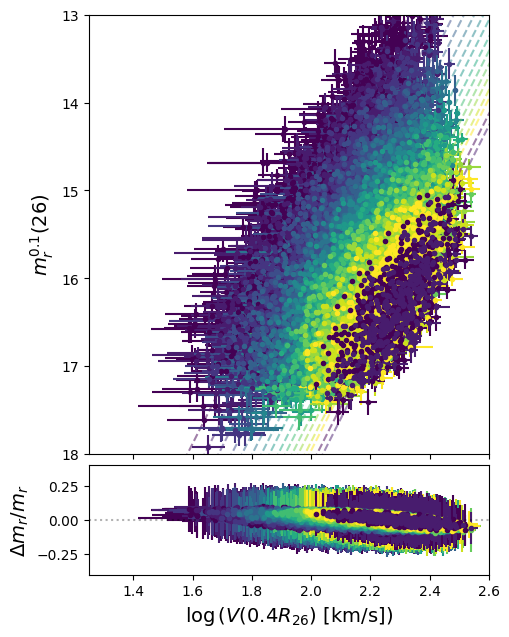

In [192]:
# fig, axes = plt.subplots(2,2, figsize=(10,7), sharex=True,
fig, axes = plt.subplots(2,1, figsize=(5,7), sharex=True,
                         gridspec_kw={'height_ratios':[4,1], 'hspace':0.04, 'wspace':0.25})

a_   = a_mcmc[1]
# b0pt = b_mcmc[0,1]
b_   = b_mcmc[:,1]#[1:]

# a_irr   = a_mcmc_irr[1]
# # b0pt = b_mcmc[0,1]
# b_irr   = b_mcmc_irr[:,1]#[1:]

#- Plot redshift bins
# ax = axes[0,0]
ax = axes[0]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

_logv = np.arange(0, 3, 0.1) - logV0
for k in range(m):
    eb = ax.errorbar(x=logV0 + logV[k],#+1], 
                     y=mag[k],#+1], 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.', 
                     label=f'{zbins[k]:.3f}-{zbins[k+1]:.3f}')

    ax.plot(_logv + logV0, a_*_logv + b_[k], color=eb[0].get_color(), ls='--', alpha=0.5)

ax.set(xlim=[1.25, 2.6],
       ylim=[18, 13])
ax.set_ylabel(r'$m_r^{0.1} (26)$', fontsize=14)
# ax.legend(loc='upper left', fontsize=9, ncol=2);
'''
#- Plot calibrators
ax = axes[0,1]
eb = ax.errorbar(x=logV[0] + logV0, y=mag[0], xerr=logV_err[0], yerr=mag_err[0],
                 fmt='.', color='tab:blue', label=f'0-pt')

ax.plot(_logv + logV0, a_*_logv + b0pt, color=eb[0].get_color(), ls='--')#, label='fit')
ax.set(xlim=[1.25, 2.6],
       ylim=[-18, -24]
      )
ax.set_ylabel(r'$M_r^{0.1}(26) = m_r^{0.1}(26) - \mu$', fontsize=14)
ax.legend(loc='upper left', fontsize=9, ncol=2)
'''
#- Plot residuals: z-bins
# ax = axes[1,0]
ax = axes[1]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

for k in range(m):
    logv_obs = logV[k]#+1]
    m_obs = mag[k]#+1]
    m_exp = (a_*logv_obs + b_[k])
    eb = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.')

ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta m_r/m_r$', fontsize=14)
'''
#- Plot residuals: calibrators
ax = axes[1,1]

logv_obs = logV[0]
m_obs = mag[0]
m_exp = (a_*logv_obs + b0pt)

b = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                xerr=logV_err[0], yerr=mag_err[0],
                fmt='.', color='tab:blue')
ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta M_r/M_r$', fontsize=14)
'''
fig.subplots_adjust(left=0.1, bottom=0.1, top=0.9, right=0.9);

# fig.savefig('../../Figures/Y1/TF_Y1_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

In [193]:
print(f'slope (alpha): {-a_/2.5:.2f} +/- {np.sqrt(cov_tfr[0,0])/2.5:.3f}')

slope (alpha): 2.67 +/- 0.014


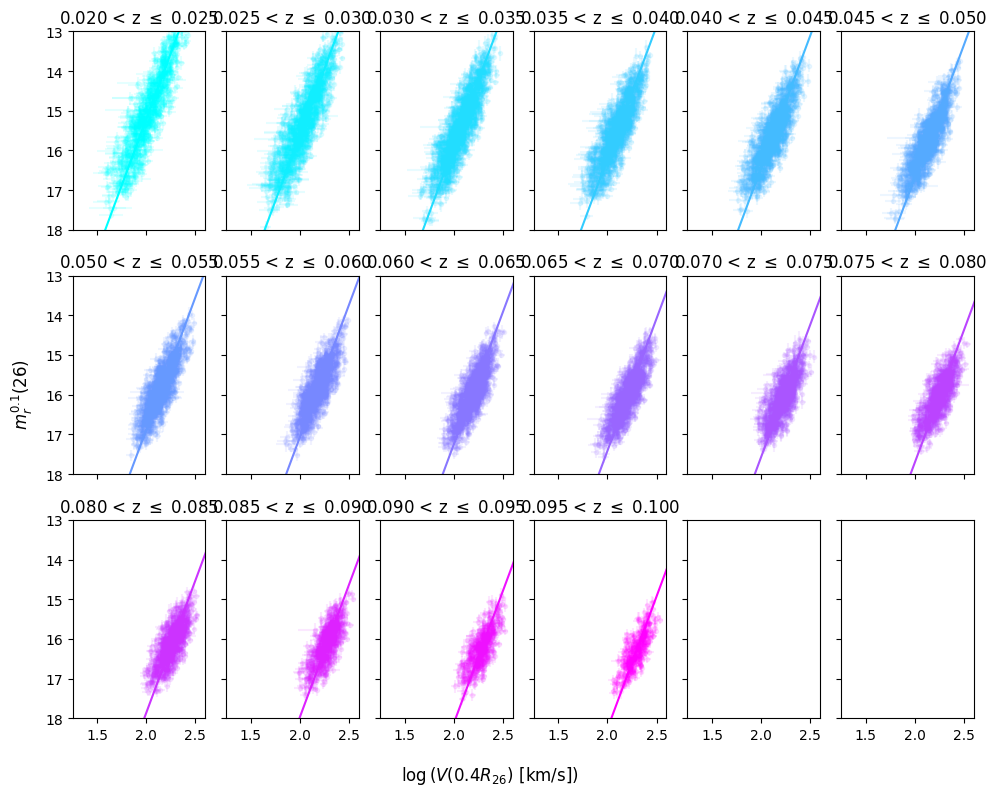

In [195]:
# fig, axs = plt.subplots(nrows=7, ncols=10, sharex=True, sharey=True, figsize=(20,16), tight_layout=True)
fig, axs = plt.subplots(nrows=3, ncols=6, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)

color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/6)
    col = i%6
    
    eb = axs[row,col].errorbar(logV0 + logV[i],#+1], 
                               mag[i],#+1], 
                               xerr=logV_err[i],#+1], 
                               yerr=mag_err[i],#+1], 
                               fmt='.', color=c, alpha=0.1)
    axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    
    axs[row,col].set(xlim=[1.25, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {zbins[i+1]:.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)')
fig.supylabel(r'$m_r^{0.1} (26)$');

# plt.savefig('../../Figures/Y1/TF_Y1_individual_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

In [196]:
for i in range(m):

    # Number of galaxies in this bin
    N_gal = len(mag[i])

    # Calculate expected magnitude given the measured V
    mag_TF = a_*logV[i] + b_[i]

    # Calculate difference between the predicted and measured magnitude
    mag_diff = mag[i] - mag_TF

    # plt.figure(tight_layout=True)
    # plt.hist(mag_diff, bins=30)
    # break

    # Calculate rms
    rms_scatter = np.sqrt(np.sum(mag_diff**2)/N_gal)
    
    print(f'{i:2d}  {zbins[i]:0.3f} < z <= {zbins[i+1]:0.3f}, {N_gal}  {rms_scatter:.2f} mag')

 0  0.020 < z <= 0.025, 942  0.52 mag
 1  0.025 < z <= 0.030, 1263  0.52 mag
 2  0.030 < z <= 0.035, 1527  0.47 mag
 3  0.035 < z <= 0.040, 1339  0.49 mag
 4  0.040 < z <= 0.045, 1313  0.48 mag
 5  0.045 < z <= 0.050, 1166  0.46 mag
 6  0.050 < z <= 0.055, 1179  0.45 mag
 7  0.055 < z <= 0.060, 1113  0.45 mag
 8  0.060 < z <= 0.065, 1164  0.44 mag
 9  0.065 < z <= 0.070, 1125  0.44 mag
10  0.070 < z <= 0.075, 976  0.48 mag
11  0.075 < z <= 0.080, 924  0.44 mag
12  0.080 < z <= 0.085, 927  0.44 mag
13  0.085 < z <= 0.090, 696  0.43 mag
14  0.090 < z <= 0.095, 503  0.44 mag
15  0.095 < z <= 0.100, 377  0.39 mag


In [197]:
# zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
# m = len(tfr_params_mcmc)-2
# ncols=6
# fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
#                         facecolor='none', dpi=150)
# # fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
# m = len(m)
# color = iter(plt.cm.cool(np.linspace(0,1,m)))
# for i in range(m):
#     c = next(color)
    
#     row = int(i/ncols)
#     col = i%ncols
    
#     eb = axs[row,col].errorbar(np.log10(sgatab['V_0p4R26'][zbin_indices==i+1]),#+1], 
#                                sgatab['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
#                                xerr=0.43*sgatab['V_0p4R26_ERR'][zbin_indices==i+1]/sgatab['V_0p4R26'][zbin_indices==i+1],#+1], 
#                                yerr=sgatab['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
#                                fmt='.', color=c, ecolor='lightgray', alpha=0.2)
#     # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
#     plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
#                  n_std = sigma, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)

    
#     # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
#     axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color='k', zorder=6)
#     # axs[row,col].plot(_logv + logV0_irr, a_irr*_logv + b_irr[i], color='red', zorder=6)
#     axs[row,col].set(xlim=[1, 2.8], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# # Delete extra axes
# # fig.delaxes(axs[-1,-1])

# fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
# fig.supylabel(r'$m_r (26)$', fontsize=20);

# # plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_v3_bin_ellipses_postfit.png', 
# #             dpi=150, 
# #             facecolor='none')


# Calculate logdistance ratios

In [198]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)
# cosmo = DESI()

# sgatab['MU_ZCMB'] = cosmo.distmod(sgatab['Z_DESI_CMB'])
# update to properly account for which redshift belong where, consistent with FP
# sgatab['MU_ZCMB'] = 5*np.log10(cosmo.comoving_distance(sgatab["Z_DESI_CMB"]).value * (1 + sgatab["Z_DESI"]))+25


sgatab['R_ABSMAG_SB26'] = sgatab['R_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value

In [199]:
rng = np.random.default_rng()

N_samples = 1000

mu_err = np.empty(len(sgatab['MU_ZCMB']))*u.mag

for i in tqdm(range(len(mu_err))):
    
    z_desi_random = rng.normal(np.abs(sgatab['Z_DESI_CMB'][i]), 
                               sgatab['ZERR_DESI'][i], 
                               N_samples)
    
    mu_random = cosmo.distmod(z_desi_random)
    
    mu_err[i] = np.std(mu_random)

sgatab['MU_ZCMB_ERR'] = mu_err

sgatab['R_ABSMAG_SB26_ERR'] = np.sqrt(sgatab['R_MAG_SB26_ERR_CORR']**2 + sgatab['MU_ZCMB_ERR'].value**2)

100%|██████████| 35578/35578 [00:47<00:00, 741.92it/s]


In [200]:
# Center redshift values of each bin
zmin = 0.02
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)
zc = 0.5*dz + zbins[:-1]

# Distance modulus for each redshift bin center
mu_zc = cosmo.distmod(zc)

In [201]:
slopes = tfr_mcmc_samples[0,:100000]
slope = np.median(tfr_mcmc_samples[0])
slope_err = np.sqrt(cov_tfr[0,0])

# Each redshift bin has its own 0pt
# To put it in absolute-magnitude space, we'll convert it to an absolute magnitude using the middle of the redshift bin
ZPs = tfr_mcmc_samples[1:-1,:100000] - mu_zc[:,None].value
ZP = np.median(tfr_mcmc_samples[1:-1], axis=1) - mu_zc.value
ZP_err = np.sqrt(np.diagonal(cov_tfr[1:-1,1:-1])) # Should include z-bin width to this uncertainty

sig = np.median(tfr_mcmc_samples[-1])

logv = np.linspace(-1*np.ones(len(zbins)-1), 3.5*np.ones(len(zbins)-1), 100)
absmag = slope*(logv - logV0) + ZP

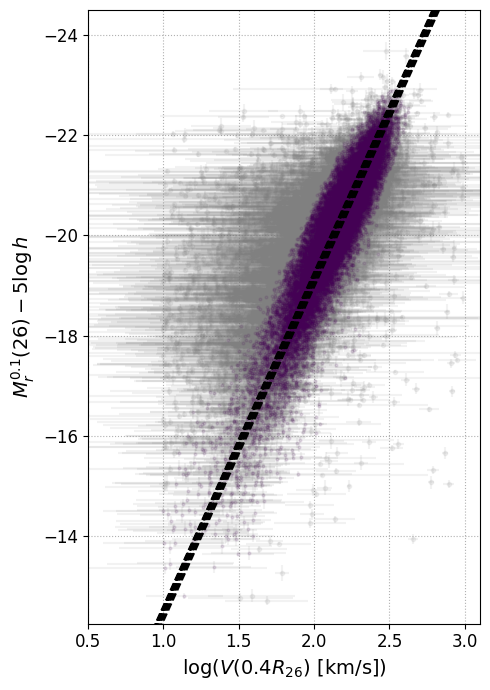

In [202]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray')

sample = outlier_boolean# & morph_boolean
plt.errorbar(sgatab['logV_SBcorr'][sample], 
             sgatab['R_ABSMAG_SB26'][sample], 
             xerr=sgatab['logV_SBcorr_err'][sample],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~outlier_boolean# & morph_boolean
plt.errorbar(sgatab['logV_SBcorr'][sample], 
             sgatab['R_ABSMAG_SB26'][sample], 
             xerr=sgatab['logV_SBcorr_err'][sample],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
             fmt='.', 
             markersize=4, 
             alpha=0.1, 
             ecolor='gray')

# sample = ~outlier_boolean_alt & outlier_boolean
# plt.errorbar(np.log10(sgatab['V_0p4R26'][sample]), 
#              sgatab['R_ABSMAG_SB26'][sample], 
#              xerr=0.434*sgatab['V_0p4R26_ERR'][sample]/sgatab['V_0p4R26'][sample],
#              yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
#              fmt='.', 
#              markersize=4, 
#              alpha=0.2, 
#              ecolor='gray')



plt.plot(logv, absmag, 'k--', zorder=3)

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -24.5])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=12);

# plt.savefig('../../Figures/Y1/iron_jointTFR_varyV0-perpdwarf_z0p1_Anthony2_weightsVmax-1_dVsys_20250717.png', 
#             dpi=150, 
#             facecolor='none')

Text(0, 0.5, '$M_r(26)$')

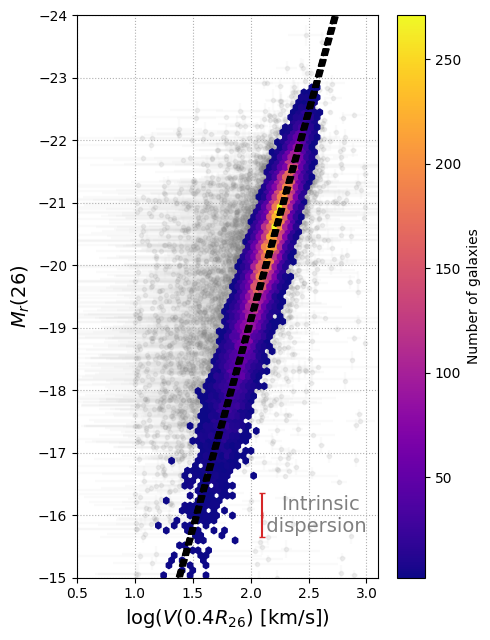

In [203]:
plt.figure(figsize=(5,6.5), tight_layout=True)
plt.grid(ls=':')

plt.errorbar(sgatab['logV_SBcorr'][outlier_boolean], 
             sgatab['R_ABSMAG_SB26'][outlier_boolean], 
             xerr=sgatab['logV_SBcorr_err'][outlier_boolean],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][outlier_boolean], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='lightgray', zorder=1)

plt.hexbin(sgatab['logV_SBcorr'][~outlier_boolean], 
           sgatab['R_ABSMAG_SB26'][~outlier_boolean], 
           cmap='plasma', 
           mincnt=2, 
           gridsize=(70,80), 
           extent=(-0.1, 3.1, -25, -12.25), zorder=2)
plt.colorbar(label='Number of galaxies')

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray', alpha=0.2)
plt.plot(logv, absmag, 'k--', zorder=3)


plt.errorbar([2.1], [-16], 
             xerr=0,
             yerr=sig, 
             ecolor='tab:red', 
             capsize=2)
plt.annotate('Intrinsic \n dispersion', 
             (3, -16), 
             va='center',
             ha='right',
             c='gray',
             fontsize=14)

plt.xlim([0.5, 3.1])
plt.ylim([-15, -24])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r(26)$', fontsize=14)

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/Y3_tfr_hexbin_hyperfit_v5a.png', 
#             dpi=150, 
#             facecolor='none')

## Store TFR fit parameters

In [204]:
###### Write to a table
tfr_params = Table([mu_zc, ZP, ZP_err],
    names=['MU_BIN', 'B', 'B_ERR'])

hdr = fits.Header()

hdr['A_SPIRAL'] = slope
hdr['A_SPIRAL_ERR'] = slope_err
# hdr['A_IRR'] = slope_irr
# hdr['A_IRR_ERR'] = slope_irr_err
hdr['LOGV0'] = logV0
hdr['ZMIN'] = 0.01
hdr['ZMAX'] = 0.10
hdr['ZBIN_WIDTH']=0.005


empty_primary = fits.PrimaryHDU(header=hdr)
table_hdu = fits.BinTableHDU(data=tfr_params)

hdul = fits.HDUList([empty_primary, table_hdu])

# # Write results to file
hdul.writeto('../TF_Y3_TFR_fit_params_v6a-zmin0p02.fits', 
             overwrite=True)

#### Redshift distribution

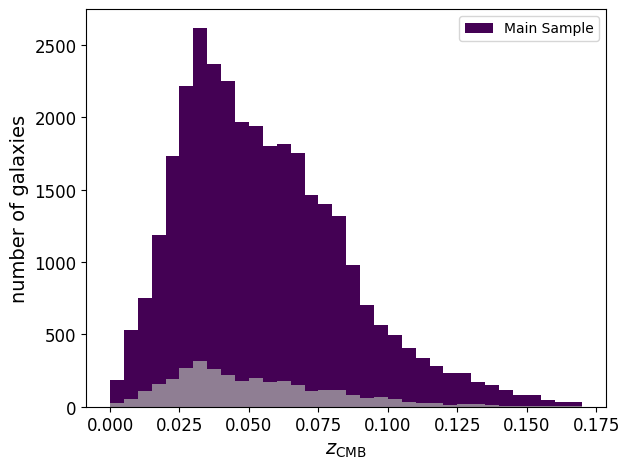

In [205]:
plt.figure(tight_layout=True)

plt.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
         bins=np.arange(0, 0.175, 0.005), label='Main Sample')
plt.hist(sgatab['Z_DESI_CMB'][outlier_boolean],
         bins=np.arange(0, 0.175, 0.005), 
         color='darkgray',
         alpha=0.75, label='')

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel('number of galaxies', fontsize=14)
plt.legend()
# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_v3_histogram_z.png', 
#             dpi=150, 
#             facecolor='none')

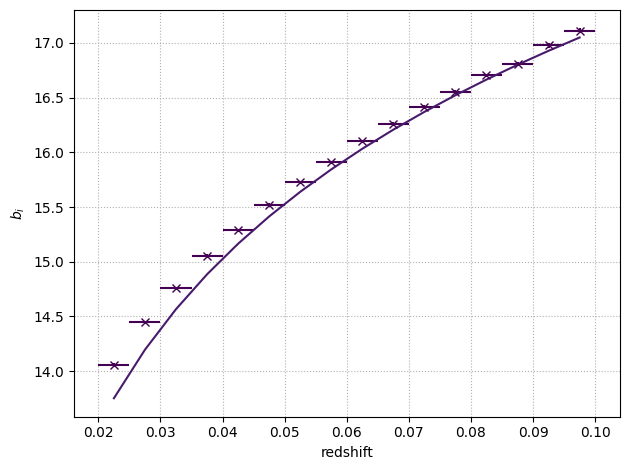

In [206]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.errorbar(zc, np.median(tfr_mcmc_samples[1:-1], axis=1), 
             xerr=0.5*dz, 
             yerr=ZP_err, 
             fmt='x')

plt.plot(zc, mu_zc-20.43*u.mag, label=r'$\mu (\Omega_{m,0}=0.3151, h=1) - 20.17$')
# plt.xlim(0.028, 0.102)
# plt.ylim(-20.5, -20.7)

plt.xlabel('redshift')
plt.ylabel('$b_i$');

# Distance moduli

In [207]:
# First, match each galaxy to its redshift bin
zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)

# For those galaxies that fall outside the calibration range, assign them to the closest bin
zbin_indices[zbin_indices == 0] = 1
zbin_indices[zbin_indices == len(zbins)] = len(zbins) - 1

# Then, use that galaxy's redshift bin's zero-point to calculate the distance modulus
sgatab['R_ABSMAG_SB26_TF'] = np.nan
for i in range(len(sgatab)):
    sgatab['R_ABSMAG_SB26_TF'][i] = slope*(sgatab['logV_SBcorr'][i] - logV0) + ZP[zbin_indices[i] - 1]

In [208]:
sgatab['R_ABSMAG_SB26_TF_ERR'] = np.nan
sgatab['R_ABSMAG_SB26_TF_ERR_STAT'] = np.nan

rng = np.random.default_rng()

for i in tqdm(range(len(sgatab))):
    
    v_random = rng.normal(10**sgatab['logV_SBcorr'][i], 
                          (10**sgatab['logV_SBcorr'][i])*sgatab['logV_SBcorr_err'][i]/0.434, 
                          # size=10000)
                          size=len(slopes))
    v_random_good = v_random[v_random > 0]

    ############################################################################
    # Statistical uncertainty
    #---------------------------------------------------------------------------
    Ms_stat = slope*(np.log10(v_random_good) - logV0) + ZP[zbin_indices[i] - 1]

    sgatab['R_ABSMAG_SB26_TF_ERR_STAT'][i] = np.nanstd(Ms_stat)
    #######################################################################
    ############################################################################
    # Total uncertainty
    #---------------------------------------------------------------------------
    Ms = slopes[v_random > 0]*(np.log10(v_random_good) - logV0) + ZPs[zbin_indices[i] - 1,v_random > 0]
    
    sgatab['R_ABSMAG_SB26_TF_ERR'][i] = np.sqrt(np.nanstd(Ms)**2 + sig**2)
    ############################################################################
    

################################################################################
# Systematic uncertainty
#-------------------------------------------------------------------------------
sgatab['R_ABSMAG_SB26_TF_ERR_SYS'] = np.sqrt(sgatab['R_ABSMAG_SB26_TF_ERR']**2 - sgatab['R_ABSMAG_SB26_TF_ERR_STAT']**2)
################################################################################

100%|██████████| 35578/35578 [04:45<00:00, 124.65it/s]


In [209]:
def profile_histogram(x, y, xbins, yerr=None, weights=None, median=False, weighted=False):
    """Compute a profile histogram from scattered data.
    
    Parameters
    ----------
    x : list or ndarray
        Ordinates (independent variable).
    y : list or ndarray
        Coordinates (dependent variable).
    xbins : list or ndarray
        Bin edges for the independent variable.
    yerr : list or ndarray
        Uncertainties on the dependent variable. Assumed independent.
    weights : list or ndarray
        If not None (and weighted=True), will use this instead of yerr to weight 
        the summary statistics.
    median : bool
        If true, compute median as central value; else, the (weighted) mean.
    weighted : bool
        Weight the summary statistics, either by the uncertainty in y or the 
        provided weights.
        
    Returns
    -------
    N : ndarray
        Unweighted counts per bin.
    h : ndarray
        Summary statistic (mean or median) of independent variable per bin.
    e : ndarray
        Uncertainty on the summary statistic per bin.
    """
    
    N = binned_statistic(x, y, bins=xbins, statistic='count').statistic

    if weighted:
        if (yerr is None) and (weights is None):
            raise ValueError('need to define either yerr or weights if using weighted fit.')

        if weights is None:
            # weight based on yerr
            w = 1/yerr**2
        else:
            w = weights
        W, H, E = binned_statistic(x, [w, w*y, w*y**2], bins=xbins, statistic='sum').statistic
        h = H/W
        e = 1/np.sqrt(W)
    else:
        mean, mean2 = binned_statistic(x, [y, y**2], bins=xbins, statistic='mean').statistic
        h = mean
        e = np.sqrt((mean2 - mean**2) / (N - 1))

    if median:
        h = binned_statistic(x, y, bins=xbins, statistic='median').statistic
    
    return N, h, e

## Compute distance modulus based on our TFR

In [210]:
# sgatab = vstack([sgatab_spirals, sgatab_irr])

In [211]:
sgatab['MU_TF'] = sgatab['R_MAG_SB26_CORR'] - sgatab['R_ABSMAG_SB26_TF']

sgatab['MU_TF_ERR'] = np.sqrt(sgatab['R_MAG_SB26_ERR_CORR']**2 + sgatab['R_ABSMAG_SB26_TF_ERR']**2)

## $\Delta M_r$ v. redshift

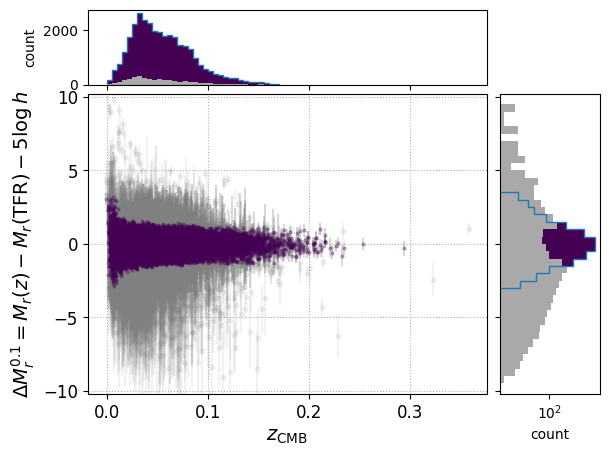

In [212]:
fig = plt.figure()

gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1,0])

sample = outlier_boolean# & morph_boolean
ax.errorbar(sgatab['Z_DESI_CMB'][sample], 
             sgatab['R_ABSMAG_SB26'][sample] - sgatab['R_ABSMAG_SB26_TF'][sample], 
             xerr=sgatab['ZERR_DESI'][sample], 
             yerr=sgatab['MU_TF_ERR'][sample],
             fmt='.', 
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~outlier_boolean
ax.errorbar(sgatab['Z_DESI_CMB'][sample], 
             sgatab['R_ABSMAG_SB26'][sample] - sgatab['R_ABSMAG_SB26_TF'][sample], 
             xerr=sgatab['ZERR_DESI'][sample], 
             yerr=sgatab['MU_TF_ERR'][sample],
             fmt='.', 
             markersize=4, 
             alpha=0.3, 
             ecolor='gray')

ax.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_xlabel(r'$z_{\text{CMB}}$', fontsize=14)
ax.set_ylabel(r'$\Delta M_r^{0.1} = M_r(z) - M_r(\text{TFR}) - 5\log h$', fontsize=14)

ax.set_ylim((-10.2, 10.2))


ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histx.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
              bins=np.arange(0, 0.175, 0.005))
ax_histx.hist(sgatab['Z_DESI_CMB'][outlier_boolean],
              bins=np.arange(0, 0.175, 0.005), 
              color='darkgray')
ax_histx.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
              bins=np.arange(0, 0.175, 0.005), 
              color='tab:blue', 
              histtype='step')

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel('count')


ax_histy = fig.add_subplot(gs[1,1], sharey=ax)
sample1 = ~outlier_boolean
sample2 = outlier_boolean
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample1] - sgatab['R_ABSMAG_SB26_TF'][sample1], 
              bins=np.arange(-12.5, 10, 0.5), 
              orientation='horizontal')
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample2] - sgatab['R_ABSMAG_SB26_TF'][sample2], 
              bins=np.arange(-12.5, 10, 0.5), 
              color='darkgray', 
              orientation='horizontal')
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample1] - sgatab['R_ABSMAG_SB26_TF'][sample1], 
              bins=np.arange(-12.5, 10, 0.5), 
              orientation='horizontal', 
              histtype='step', 
              color='tab:blue')

ax_histy.set_xscale('log')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel('count');

## $\eta$ v. redshift

In [213]:
sgatab['LOGDIST'] = 0.2*(sgatab['MU_ZCMB'] - sgatab['MU_TF'])
sgatab['LOGDIST_ERR'] = 0.2*np.sqrt(sgatab['MU_ZCMB_ERR']**2 + sgatab['MU_TF_ERR']**2)

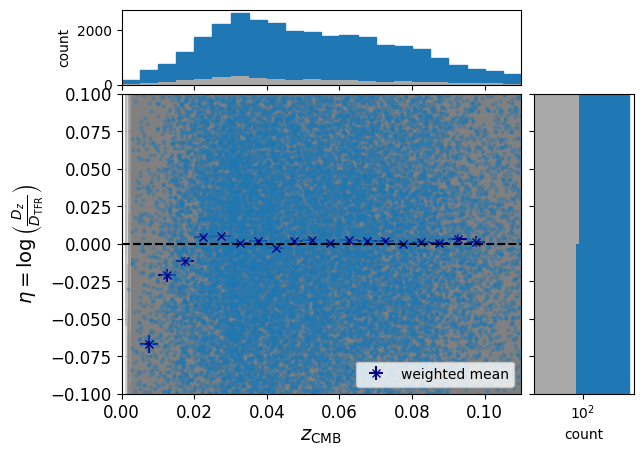

In [214]:
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1 = ~outlier_boolean
sample2 = outlier_boolean

fig = plt.figure()

gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1,0])

ax.errorbar(sgatab['Z_DESI_CMB'][sample2], 
             sgatab['LOGDIST'][sample2], 
             xerr=sgatab['ZERR_DESI'][sample2], 
             yerr=sgatab['LOGDIST_ERR'][sample2],
             fmt='.', 
             color='gray',
             alpha=0.1, 
             ecolor='gray')

ax.errorbar(sgatab['Z_DESI_CMB'][sample1], 
             sgatab['LOGDIST'][sample1], 
             xerr=sgatab['ZERR_DESI'][sample1], 
             yerr=sgatab['LOGDIST_ERR'][sample1],
             fmt='.', 
             markersize=4, 
             alpha=0.3,
             color='tab:blue',
             ecolor='gray')

# Plot the weighted mean
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
ax.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='weighted mean')
'''
# Plot the median
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['R_LOGDIST'][sample1], 
                                    zbins, 
                                    median=True)
ax.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='lightsteelblue', label='median')
'''
# Line at eta = 0
ax.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)

ax.legend()

ax.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_xlabel(r'$z_{\text{CMB}}$', fontsize=14)
ax.set_ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', fontsize=14)

# ax.set_ylim((-1.9, 1.9))
ax.set_xlim((0, 0.2))
# ax.set_ylim((-0.5, 0.5))
ax.set_ylim((-0.1, 0.1))
ax.set_xlim((0, 0.11))

ax.grid(ls=':')


ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histx.hist(sgatab['Z_DESI_CMB'][sample1], 
              color='tab:blue',
              bins=np.arange(0, 0.175, 0.005))
ax_histx.hist(sgatab['Z_DESI_CMB'][sample2], 
              bins=np.arange(0, 0.175, 0.005), 
              color='darkgray')
ax_histx.hist(sgatab['Z_DESI_CMB'][sample1], 
              bins=np.arange(0, 0.175, 0.005), 
              color='tab:blue', 
              histtype='step')

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel('count')


ax_histy = fig.add_subplot(gs[1,1], sharey=ax)
ax_histy.hist(sgatab['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.1),
              color='tab:blue',
              orientation='horizontal')
ax_histy.hist(sgatab['LOGDIST'][sample2], 
              bins=np.arange(-2, 2, 0.1), 
              color='darkgray', 
              orientation='horizontal')
ax_histy.hist(sgatab['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.1), 
              orientation='horizontal', 
              histtype='step',
              color='tab:blue')

ax_histy.set_xscale('log')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel('count');

# plt.savefig('../../Figures/Y1/iron_logdist-v-z_jointTFR-varyV0-perpdwarfs_z0p1_Anthony2_weightsVmax-1_dVsys_20250717.png', 
#             dpi=150, 
#             facecolor='none', 
#             bbox_inches='tight');

/tmp/ipykernel_539951/1711612909.py:27: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


(0.0, 0.105)

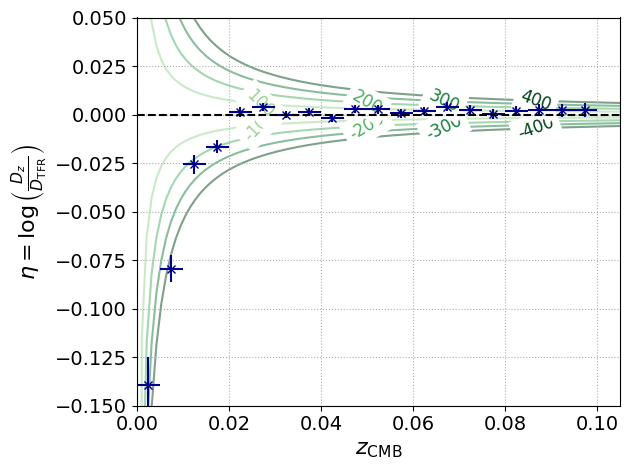

In [215]:
plt.figure(tight_layout=True)

# zbins = np.arange(0, 0.1025, 0.0025)
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1=sgatab['MAIN']
# sample1=~outlier_boolean
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='Main sample')



# PV lines (code taken from Cullen)
c = const.c.to('km/s')
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.5, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both',
                which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

plt.ylim((-0.15, 0.05))
# plt.ylim((-0.12, 0.1))
# plt.ylim((-0.2, 0.2))
plt.xlim((0, 0.105))
# plt.xlim((0, 0.2))

# plt.legend(loc='lower right');

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_DR2_eta_z_v5a.png',facecolor='none', dpi=150)

/tmp/ipykernel_539951/2807516743.py:45: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


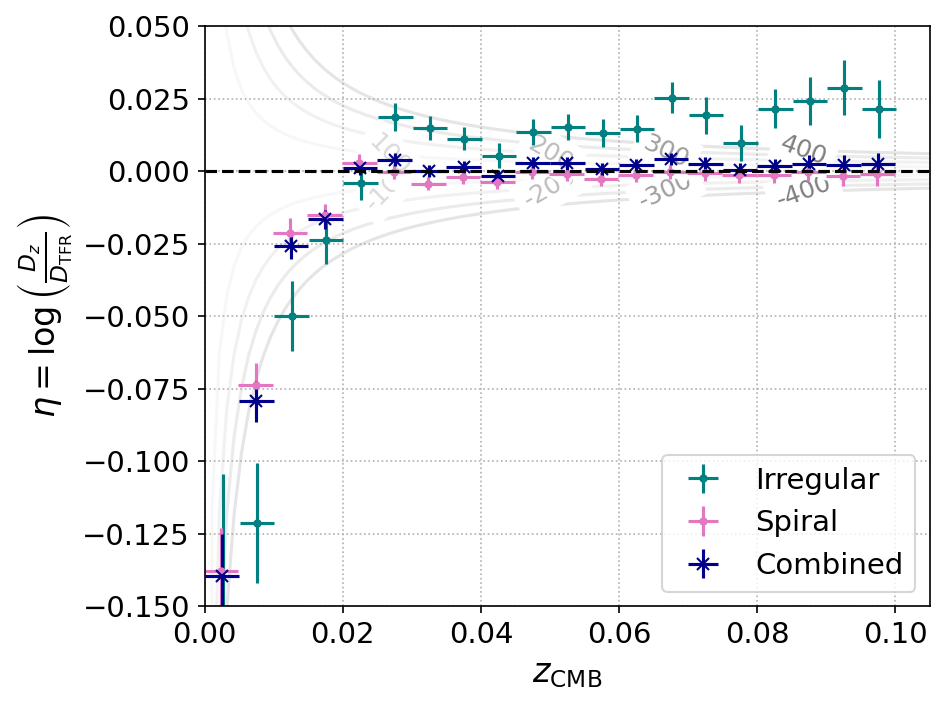

In [216]:
plt.figure(tight_layout=True,dpi=150, facecolor='none')

# zbins = np.arange(0, 0.1025, 0.0025)
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1=((sgatab['MAIN']) & (sgatab['MORPHTYPE']=='Spiral'))
sample2=((sgatab['MAIN']) & (sgatab['MORPHTYPE']=='Irregular'))
sample3=((sgatab['MAIN']))


N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample2], 
                                    sgatab['LOGDIST'][sample2], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample2]**-2, 
                                    weighted=True)
plt.errorbar(zc+0.0001, y_avg, xerr=dz, yerr=y_std, fmt='.', color='teal', label='Irregular')

N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc-0.0001, y_avg, xerr=dz, yerr=y_std, fmt='.', color='tab:pink', label='Spiral')

N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample3], 
                                    sgatab['LOGDIST'][sample3], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample3]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='Combined')




# PV lines (code taken from Cullen)
c = const.c.to('km/s')
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greys(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.1, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1, alpha=0.5)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)


plt.ylim(-0.15, 0.05)
# plt.ylim((-0.12, 0.1))
# plt.ylim((-0.2, 0.2))
plt.xlim(0, 0.105)
# plt.xlim((0, 0.2))

plt.legend(loc='lower right', fontsize=14);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_DR2_eta_z_spiral_irr_v5a_.png',facecolor='none', dpi=150)

In [217]:
np.sum(sgatab['MAIN'])

28984

In [218]:
np.unique(sgatab['MORPHTYPE'][sgatab['MAIN']], return_counts=True)

(<MaskedColumn name='MORPHTYPE' dtype='bytes21' length=2>
 Irregular
    Spiral,
 array([ 5905, 23079]))

In [219]:
np.sum(sgatab['MORPHTYPE']=='Irregular'), np.sum(sgatab['MORPHTYPE']=='Elliptical'), np.sum(sgatab['MORPHTYPE']=='Lenticular'), np.sum(sgatab['MORPHTYPE']=='Spiral')

(7100, 157, 236, 25388)

In [220]:
hdr = fits.Header()

hdr['DESI_DR'] = 'DR1'
hdr['V_RADIUS'] = '0.4 R26'
hdr['M'] = slope
hdr['M_ERR'] = slope_err
# hdr['M_IRR'] = slope_irr
# hdr['M_IRR_ERR'] = slope_irr_err
# hdr['0PT'] = ZP
# hdr['0PT_ERR'] = ZP_err
hdr['logV0'] = logV0
hdr['SIG'] = np.median(tfr_mcmc_samples[-1])
hdr['SIG_ERR'] = np.sqrt(cov_tfr[-1,-1])
# hdr['SIG_IRR'] = np.median(tfr_mcmc_samples_irr[-1])
# hdr['SIG_IRR_ERR'] = np.sqrt(cov_tfr_irr[-1,-1])
hdr['H0'] = H0
hdr['EL_STD'] = sigma
hdr['EL_TYPE'] = 'binned'
hdr['RINTDUST'] = internalDust_coeffs_r[0]
hdr['RINTDUST_ERR'] = internalDust_coeffs_err_r[0]

# hdr['EL_MU_X'] = ellipse_mean[0]
# hdr['EL_MU_Y'] = ellipse_mean[1]

# # Ellipse covariance matrix
# hdr['EL_COV00'] = ellipse_cov[0, 0]
# hdr['EL_COV01'] = ellipse_cov[0, 1]
# hdr['EL_COV10'] = ellipse_cov[1, 0]
# hdr['EL_COV11'] = ellipse_cov[1, 1]


empty_primary = fits.PrimaryHDU(header=hdr)

## Convert all masked elements to False before saving

In [221]:
# sgatab['MAIN'] = sgatab['MAIN'].filled(False)
# sgatab['GOOD_MORPH'] = sgatab['GOOD_MORPH'].filled(False)

In [222]:
table_hdu = fits.BinTableHDU(data=sgatab)

hdul = fits.HDUList([empty_primary, table_hdu])

# # Write results to file
hdul.writeto('eta_cats/SGA_loa_jointTFR_v6a-zmin0p02.fits', 
             overwrite=True)

In [223]:
# sgatab_this = sgatab

In [224]:
hdul.writeto('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/alternate_calibrations/DESI-DR2_TF_pv_test_cat_v6a-zmin0p02.fits', 
             overwrite=True)

# !chgrp desi /global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y1/systematic_tests/DESI-DR1_TF_pv_test_cat_v5c.fits

In [ ]:
# sgatab= Table.read('eta_cats/SGA_loa_jointTFR_v5a_unweighted_irrcal_morphcorr.fits')

In [100]:
# ! chgrp desi /global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/DESI-DR2_TF_pv_cat_v6a.fits

In [113]:
# x=Table.read('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y1/systematic_tests/DESI-DR1_TF_pv_test_cat_v5c.fits')
# y=Table.read('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y1/systematic_tests/DESI-DR1_TF_pv_test_cat_v5f.fits')

In [114]:
# np.sum(x['MAIN']), np.sum(y['MAIN'])

(8293, 6160)

In [77]:
sgatab=Table.read('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/DESI-DR2_TF_pv_cat_v6a.fits')

In [177]:
sgatab_big = sgatab[(sgatab['D26']>1)]

false_spirals = (sgatab_big['MORPHTYPE_AI'] == 'Spiral') & (sgatab_big['MORPHTYPE_VI'] == 'Irregul')
false_irrs = (sgatab_big['MORPHTYPE_VI'] == 'Spiral') & (sgatab_big['MORPHTYPE_AI'] == 'Irregular')

good_spirals = (sgatab_big['MORPHTYPE_AI'] == 'Spiral') & (sgatab_big['MORPHTYPE_VI'] == 'Spiral')
good_irrs = (sgatab_big['MORPHTYPE_AI'] == 'Irregular') & (sgatab_big['MORPHTYPE_VI'] == 'Irregul')
matches = good_spirals | good_irrs

In [161]:
np.sum(matches), np.sum(false_spirals), np.sum(false_irrs), len(sgatab_big)

(2833, 182, 1413, 4769)

In [162]:
np.sum(good_spirals), np.sum(good_irrs), np.sum(matches)

(2304, 529, 2833)

In [180]:
np.sum(good_irrs)/len(sgatab_big)

0.11092472216397567

In [181]:
np.sum(false_spirals)/len(sgatab_big)

0.03816313692598029

Text(0, 0.5, 'Count')

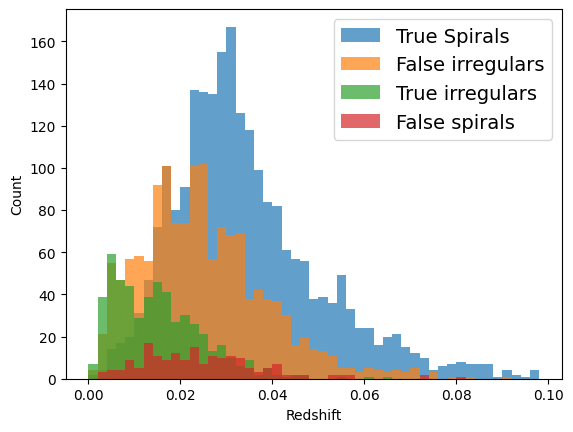

In [183]:
plt.hist(sgatab_big['Z_DESI_CMB'][good_spirals], bins=np.arange(0,0.1,0.002), alpha=0.7, label='True Spirals')
plt.hist(sgatab_big['Z_DESI_CMB'][false_irrs], bins=np.arange(0,0.1,0.002), alpha=0.7, label='False irregulars')
plt.hist(sgatab_big['Z_DESI_CMB'][good_irrs], bins=np.arange(0,0.1,0.002), alpha=0.7, label='True irregulars')
plt.hist(sgatab_big['Z_DESI_CMB'][false_spirals], bins=np.arange(0,0.1,0.002), alpha=0.7, label='False spirals')
plt.legend(fontsize=14)
plt.xlabel('Redshift')
plt.ylabel('Count')

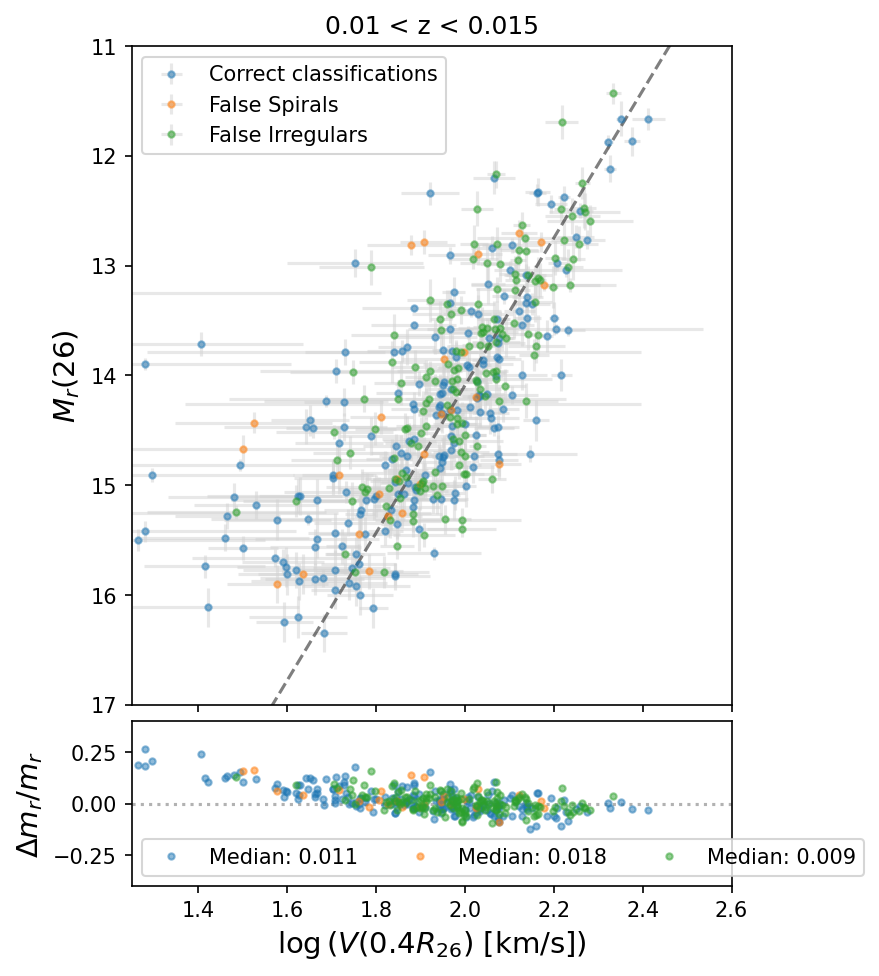

In [174]:
sgatab_big = sgatab[(sgatab['D26']>1) & (sgatab['Z_DESI_CMB']>0.01) & (sgatab['Z_DESI_CMB']<0.015)]

false_spirals = (sgatab_big['MORPHTYPE_AI'] == 'Spiral') & (sgatab_big['MORPHTYPE_VI'] == 'Irregul')
false_irrs = (sgatab_big['MORPHTYPE_VI'] == 'Spiral') & (sgatab_big['MORPHTYPE_AI'] == 'Irregular')
good_spirals = (sgatab_big['MORPHTYPE_AI'] == 'Spiral') & (sgatab_big['MORPHTYPE_VI'] == 'Spiral')
good_irrs = (sgatab_big['MORPHTYPE_AI'] == 'Irregular') & (sgatab_big['MORPHTYPE_VI'] == 'Irregul')
matches = good_spirals | good_irrs

# fig, axes = plt.subplots(2,2, figsize=(10,7), sharex=True,
fig, axes = plt.subplots(2,1, figsize=(5,7), sharex=True,
                         gridspec_kw={'height_ratios':[4,1], 'hspace':0.04, 'wspace':0.25}, dpi=150)

ax = axes[0]

# plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))
a_   = a_mcmc[1]
b_   = b_mcmc[:,1]
_logv = np.arange(0, 3, 0.1) - logV0

eb = ax.errorbar(x=sgatab_big['LOGVROT'][matches],
                 y=sgatab_big['R_MAG_SB26_CORR'][matches] ,
                 xerr=sgatab_big['LOGVROT_ERR'][matches], 
                 yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][matches],
                 fmt='.', 
                 label='Correct classifications',
                 ecolor='lightgray',
                alpha=0.5)

ax.errorbar(x=sgatab_big['LOGVROT'][false_spirals],
                 y=sgatab_big['R_MAG_SB26_CORR'][false_spirals] ,
                 xerr=sgatab_big['LOGVROT_ERR'][false_spirals], 
                 yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][false_spirals],
                 fmt='.', 
                 label='False Spirals',
            ecolor='lightgray',
           alpha=0.5)

ax.errorbar(x=sgatab_big['LOGVROT'][false_irrs],
                 y=sgatab_big['R_MAG_SB26_CORR'][false_irrs] ,
                 xerr=sgatab_big['LOGVROT_ERR'][false_irrs], 
                 yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][false_irrs],
                 fmt='.', 
                 label='False Irregulars',
            ecolor='lightgray',
           alpha=0.5)


ax.plot(_logv + logV0, a_*_logv + b_[0], color='k', ls='--', alpha=0.5)

ax.set(xlim=[1.25, 2.6],
       ylim=[17,11])
ax.set_ylabel(r'$M_r (26)$', fontsize=14)
ax.set_title('0.01 < z < 0.015')
ax.legend(loc='upper left');

#- Plot residuals: z-bins
ax = axes[1]


logv_obs = sgatab_big['LOGVROT']-logV0
m_obs = sgatab_big['R_MAG_SB26_CORR']
m_exp = (a_*logv_obs + b_[0])
eb = ax.errorbar(x=logv_obs[matches] + logV0, y=(m_exp[matches]-m_obs[matches])/m_exp[matches], 
                 # xerr=sgatab_big['LOGVROT_ERR'][matches],
                 # yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][matches],
                 fmt='.', alpha=0.5, label=f'Median: {np.median((m_exp[matches]-m_obs[matches])/m_exp[matches]):.3f}')

eb = ax.errorbar(x=logv_obs[false_spirals] + logV0, y=(m_exp[false_spirals]-m_obs[false_spirals])/m_exp[false_spirals], 
                 # xerr=sgatab_big['LOGVROT_ERR'][false_spirals],
                 # yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][false_spirals],
                 fmt='.', alpha=0.5, label=f'Median: {np.median((m_exp[false_spirals]-m_obs[false_spirals])/m_exp[false_spirals]):.3f}')

eb = ax.errorbar(x=logv_obs[false_irrs] + logV0, y=(m_exp[false_irrs]-m_obs[false_irrs])/m_exp[false_irrs], 
                 # xerr=sgatab_big['LOGVROT_ERR'][false_irrs],
                 # yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][false_irrs],
                 fmt='.', alpha=0.5, label=f'Median: {np.median((m_exp[false_irrs]-m_obs[false_irrs])/m_exp[false_irrs]):.3f}')


ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.legend(ncol=3)
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta m_r/m_r$', fontsize=14)
'''
#- Plot residuals: calibrators
ax = axes[1,1]

logv_obs = logV[0]
m_obs = mag[0]
m_exp = (a_*logv_obs + b0pt)

b = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                xerr=logV_err[0], yerr=mag_err[0],
                fmt='.', color='tab:blue')
ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta M_r/M_r$', fontsize=14)
'''
fig.subplots_adjust(left=0.1, bottom=0.1, top=0.9, right=0.9);

# fig.savefig('../../Figures/Y1/TF_Y1_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

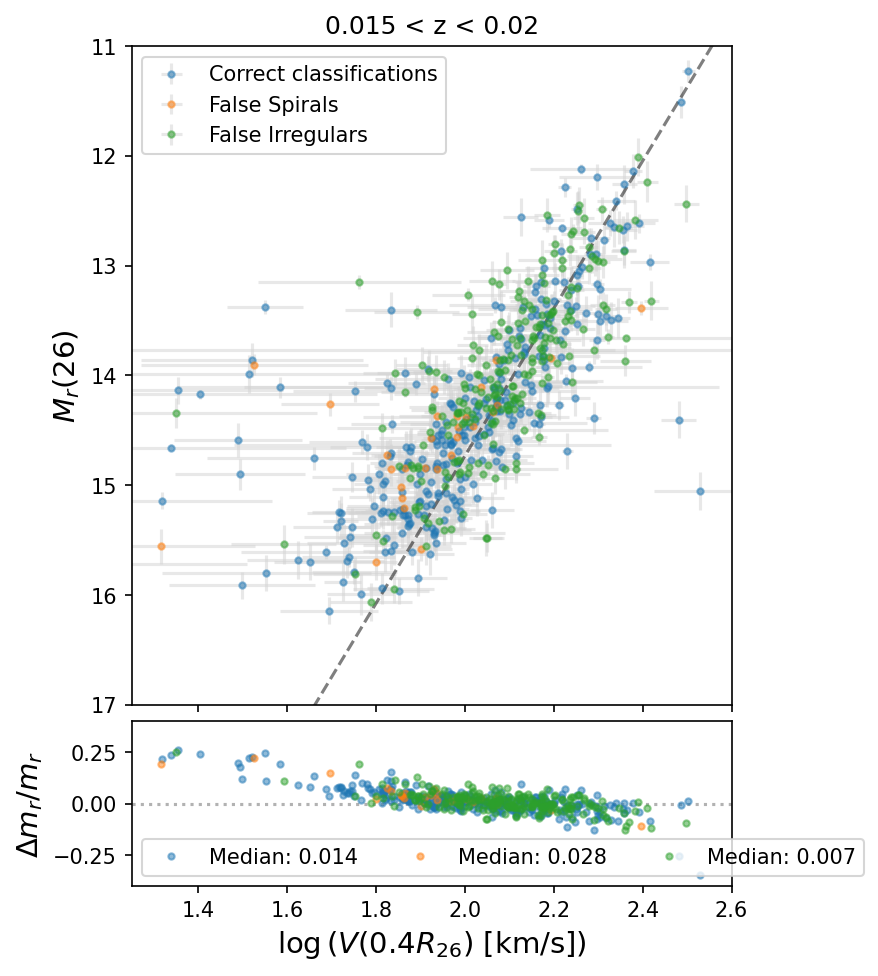

In [176]:
sgatab_big = sgatab[(sgatab['D26']>1) & (sgatab['Z_DESI_CMB']>0.015) & (sgatab['Z_DESI_CMB']<0.02)]
false_spirals = (sgatab_big['MORPHTYPE_AI'] == 'Spiral') & (sgatab_big['MORPHTYPE_VI'] == 'Irregul')
false_irrs = (sgatab_big['MORPHTYPE_VI'] == 'Spiral') & (sgatab_big['MORPHTYPE_AI'] == 'Irregular')
good_spirals = (sgatab_big['MORPHTYPE_AI'] == 'Spiral') & (sgatab_big['MORPHTYPE_VI'] == 'Spiral')
good_irrs = (sgatab_big['MORPHTYPE_AI'] == 'Irregular') & (sgatab_big['MORPHTYPE_VI'] == 'Irregul')
matches = good_spirals | good_irrs
# fig, axes = plt.subplots(2,2, figsize=(10,7), sharex=True,
fig, axes = plt.subplots(2,1, figsize=(5,7), sharex=True,
                         gridspec_kw={'height_ratios':[4,1], 'hspace':0.04, 'wspace':0.25}, dpi=150)

ax = axes[0]

# plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))
a_   = a_mcmc[1]
b_   = b_mcmc[:,1]
_logv = np.arange(0, 3, 0.1) - logV0

eb = ax.errorbar(x=sgatab_big['LOGVROT'][matches],
                 y=sgatab_big['R_MAG_SB26_CORR'][matches] ,
                 xerr=sgatab_big['LOGVROT_ERR'][matches], 
                 yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][matches],
                 fmt='.', 
                 label='Correct classifications',
                 ecolor='lightgray',
                alpha=0.5)

ax.errorbar(x=sgatab_big['LOGVROT'][false_spirals],
                 y=sgatab_big['R_MAG_SB26_CORR'][false_spirals] ,
                 xerr=sgatab_big['LOGVROT_ERR'][false_spirals], 
                 yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][false_spirals],
                 fmt='.', 
                 label='False Spirals',
            ecolor='lightgray',
           alpha=0.5)

ax.errorbar(x=sgatab_big['LOGVROT'][false_irrs],
                 y=sgatab_big['R_MAG_SB26_CORR'][false_irrs] ,
                 xerr=sgatab_big['LOGVROT_ERR'][false_irrs], 
                 yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][false_irrs],
                 fmt='.', 
                 label='False Irregulars',
            ecolor='lightgray',
           alpha=0.5)


ax.plot(_logv + logV0, a_*_logv + b_[1], color='k', ls='--', alpha=0.5)

ax.set(xlim=[1.25, 2.6],
       ylim=[17,11])
ax.set_ylabel(r'$M_r (26)$', fontsize=14)
ax.set_title('0.015 < z < 0.02')
ax.legend(loc='upper left');

#- Plot residuals: z-bins
ax = axes[1]


logv_obs = sgatab_big['LOGVROT']-logV0
m_obs = sgatab_big['R_MAG_SB26_CORR']
m_exp = (a_*logv_obs + b_[1])
eb = ax.errorbar(x=logv_obs[matches] + logV0, y=(m_exp[matches]-m_obs[matches])/m_exp[matches], 
                 # xerr=sgatab_big['LOGVROT_ERR'][matches],
                 # yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][matches],
                 fmt='.', alpha=0.5, label=f'Median: {np.median((m_exp[matches]-m_obs[matches])/m_exp[matches]):.3f}')

eb = ax.errorbar(x=logv_obs[false_spirals] + logV0, y=(m_exp[false_spirals]-m_obs[false_spirals])/m_exp[false_spirals], 
                 # xerr=sgatab_big['LOGVROT_ERR'][false_spirals],
                 # yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][false_spirals],
                 fmt='.', alpha=0.5, label=f'Median: {np.median((m_exp[false_spirals]-m_obs[false_spirals])/m_exp[false_spirals]):.3f}')


eb = ax.errorbar(x=logv_obs[false_irrs] + logV0, y=(m_exp[false_irrs]-m_obs[false_irrs])/m_exp[false_irrs], 
                 # xerr=sgatab_big['LOGVROT_ERR'][false_irrs],
                 # yerr=sgatab_big['R_MAG_SB26_ERR_CORR'][false_irrs],
                 fmt='.', alpha=0.5, label=f'Median: {np.median((m_exp[false_irrs]-m_obs[false_irrs])/m_exp[false_irrs]):.3f}')


ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.legend(ncol=3)
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta m_r/m_r$', fontsize=14)
'''
#- Plot residuals: calibrators
ax = axes[1,1]

logv_obs = logV[0]
m_obs = mag[0]
m_exp = (a_*logv_obs + b0pt)

b = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                xerr=logV_err[0], yerr=mag_err[0],
                fmt='.', color='tab:blue')
ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta M_r/M_r$', fontsize=14)
'''
fig.subplots_adjust(left=0.1, bottom=0.1, top=0.9, right=0.9);
# fig.suptitle('0.015 < z < 0.02')
# fig.savefig('../../Figures/Y1/TF_Y1_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

In [ ]:
 # fig, axes = plt.subplots(2,2, figsize=(10,7), sharex=True,
fig, axes = plt.subplots(2,1, figsize=(5,7), sharex=True,
                         gridspec_kw={'height_ratios':[4,1], 'hspace':0.04, 'wspace':0.25})

a_   = a_mcmc[1]
# b0pt = b_mcmc[0,1]
b_   = b_mcmc[:,1]#[1:]

# a_irr   = a_mcmc_irr[1]
# # b0pt = b_mcmc[0,1]
# b_irr   = b_mcmc_irr[:,1]#[1:]

#- Plot redshift bins
# ax = axes[0,0]
ax = axes[0]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

_logv = np.arange(0, 3, 0.1) - logV0
for k in range(m):
    eb = ax.errorbar(x=logV0 + logV[k],#+1], 
                     y=mag[k],#+1], 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.', 
                     label=f'{zbins[k]:.3f}-{zbins[k+1]:.3f}')

    ax.plot(_logv + logV0, a_*_logv + b_[k], color=eb[0].get_color(), ls='--', alpha=0.5)

ax.set(xlim=[1.25, 2.6],
       ylim=[18, 13])
ax.set_ylabel(r'$m_r^{0.1} (26)$', fontsize=14)
# ax.legend(loc='upper left', fontsize=9, ncol=2);
'''
#- Plot calibrators
ax = axes[0,1]
eb = ax.errorbar(x=logV[0] + logV0, y=mag[0], xerr=logV_err[0], yerr=mag_err[0],
                 fmt='.', color='tab:blue', label=f'0-pt')

ax.plot(_logv + logV0, a_*_logv + b0pt, color=eb[0].get_color(), ls='--')#, label='fit')
ax.set(xlim=[1.25, 2.6],
       ylim=[-18, -24]
      )
ax.set_ylabel(r'$M_r^{0.1}(26) = m_r^{0.1}(26) - \mu$', fontsize=14)
ax.legend(loc='upper left', fontsize=9, ncol=2)
'''
#- Plot residuals: z-bins
# ax = axes[1,0]
ax = axes[1]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

for k in range(m):
    logv_obs = logV[k]#+1]
    m_obs = mag[k]#+1]
    m_exp = (a_*logv_obs + b_[k])
    eb = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.')

ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta m_r/m_r$', fontsize=14)
'''
#- Plot residuals: calibrators
ax = axes[1,1]

logv_obs = logV[0]
m_obs = mag[0]
m_exp = (a_*logv_obs + b0pt)

b = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                xerr=logV_err[0], yerr=mag_err[0],
                fmt='.', color='tab:blue')
ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta M_r/M_r$', fontsize=14)
'''
fig.subplots_adjust(left=0.1, bottom=0.1, top=0.9, right=0.9);

# fig.savefig('../../Figures/Y1/TF_Y1_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')